## Данные

### Загрузка данных в колаб

Поскольку нам нужно загрузить датасет, сделаем это с помощью гугл диска

#### Через ваш гугл диск

смонтирую диск

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


скопируем датасет

In [ ]:
!cp /content/drive/MyDrive/ml-intensive-yandex-academy-spring-2026.zip /content/dataset.zip

#### Через ссылку на гугл диске (2 способ для тестирования)

к тестам [тык](#scrollTo=LW8t_SMsMLxc)

In [ ]:
!pip install gdown -q

In [ ]:
import gdown

url = "https://drive.google.com/uc?id=1npMBxESwZ3nZnOENJAOHnIVVX745F5_O"
output = "/content/dataset.zip"

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1npMBxESwZ3nZnOENJAOHnIVVX745F5_O
From (redirected): https://drive.google.com/uc?id=1npMBxESwZ3nZnOENJAOHnIVVX745F5_O&confirm=t&uuid=fe6275ed-3fbd-4e58-b6d3-18abfa0c62cd
To: /content/dataset.zip
100%|██████████| 2.68G/2.68G [00:52<00:00, 51.4MB/s]


'/content/dataset.zip'

#### Распакуем датасет

In [ ]:
!unzip /content/dataset.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: dataset/train_images/55.jpg  
  inflating: dataset/train_images/550.jpg  
  inflating: dataset/train_images/5500.jpg  
  inflating: dataset/train_images/5501.jpg  
  inflating: dataset/train_images/5502.jpg  
  inflating: dataset/train_images/5503.jpg  
  inflating: dataset/train_images/5504.jpg  
  inflating: dataset/train_images/5505.jpg  
  inflating: dataset/train_images/5506.jpg  
  inflating: dataset/train_images/5507.jpg  
  inflating: dataset/train_images/5508.jpg  
  inflating: dataset/train_images/5509.jpg  
  inflating: dataset/train_images/551.jpg  
  inflating: dataset/train_images/5510.jpg  
  inflating: dataset/train_images/5511.jpg  
  inflating: dataset/train_images/5512.jpg  
  inflating: dataset/train_images/5513.jpg  
  inflating: dataset/train_images/5514.jpg  
  inflating: dataset/train_images/5515.jpg  
  inflating: dataset/train_images/5516.jpg  
  inflating: dataset/train_images/55

### Анализ данных

Для начала посмотрим количество классов

In [ ]:
import pandas as pd

df = pd.read_csv('dataset/train_solution.csv')
df.columns = ['image_id', 'label']
print("Количество объектов по классам:")
print(df.iloc[:, 1].value_counts())

print("\nПроцентное соотношение:")
print(df.iloc[:, 1].value_counts(normalize=True) * 100)

Количество объектов по классам:
label
0    41499
1     8500
Name: count, dtype: int64

Процентное соотношение:
label
0    82.99966
1    17.00034
Name: proportion, dtype: float64


В датасете присутствует дизбаланс классов: класс real (0) в 4,88 больше класса fake (1)

Если мы откроем типичное изображение из датасета, то увидим очень много шума salt and paper:

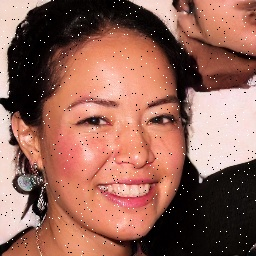

In [ ]:
from PIL import Image

img = Image.open('/content/dataset/test_images/0.jpg')

img

Проверим размеры изображений

In [ ]:
import os
from tqdm import tqdm

widths, heights = [], []
for img_name in tqdm(os.listdir('/content/dataset/train_images/')):
    with Image.open(f'/content/dataset/train_images/{img_name}') as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

pd.Series(zip(widths, heights)).value_counts()

100%|██████████| 50000/50000 [00:15<00:00, 3212.27it/s]


,count
"(256, 256)",50000


Проверим изображения на полные дубликаты

In [ ]:
import hashlib

def get_image_hash(img_path):
    with open(img_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = []

train_path = '/content/dataset/train_images/'
for img_name in os.listdir(train_path):
    path = os.path.join(train_path, img_name)
    h = get_image_hash(path)
    if h in hashes:
        duplicates.append((img_name, hashes[h]))
    else:
        hashes[h] = img_name

print(f"Найдено полных дубликатов: {len(duplicates)}")

Найдено полных дубликатов: 0


Выведем картинки с их обозначением (real/fake) для наглядности

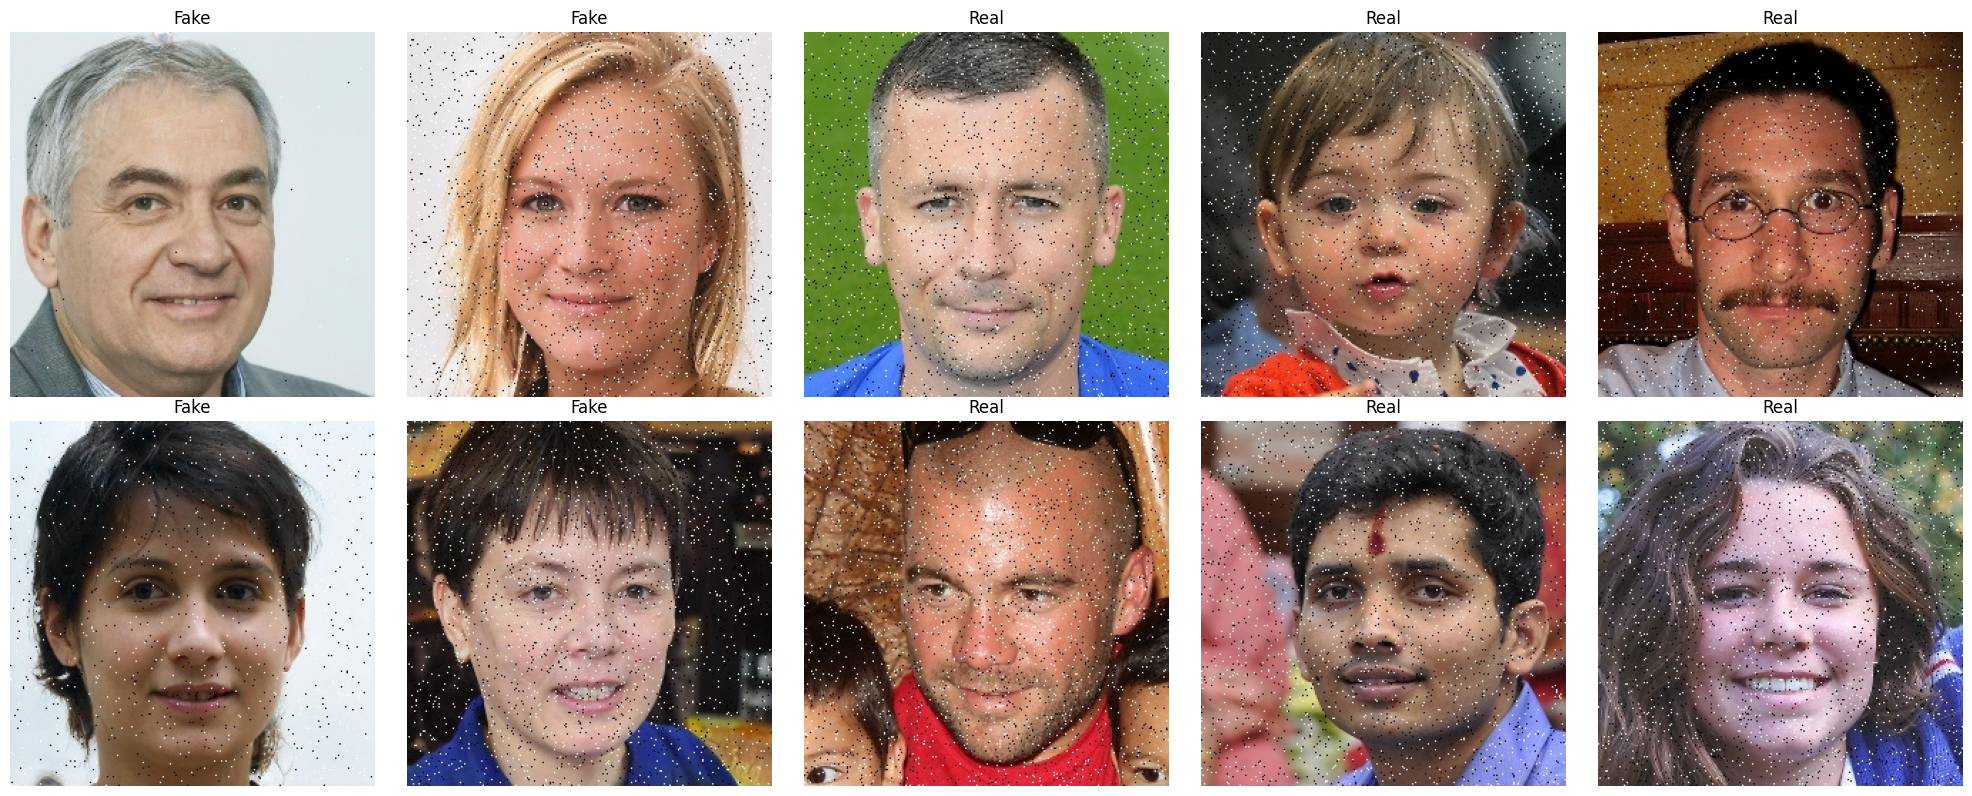

In [ ]:
def plot_image_grid(image_paths, labels=None, rows=2, cols=5):
    fig, axes = plt.subplots(rows, cols, figsize=(20, 8))
    axes = axes.flatten()

    for i, img_path in enumerate(image_paths):
        if i >= len(axes): break

        img = Image.open(img_path)
        axes[i].imshow(img)
        title = labels[i] if labels is not None else os.path.basename(img_path)
        axes[i].set_title(title)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# берем первые 10 картинок из датафрейма
sample_df = df.head(10)
paths = ['/content/dataset/train_images/' + str(fname) + ".jpg" for fname in sample_df['image_id']]
labels = ['Fake' if l == 1 else 'Real' for l in sample_df['label']]

plot_image_grid(paths, labels)

### Работа с данными

#### **Борьба с salt and paper**

In [ ]:
import numpy as np
import cv2

# в общем к что я узнал за 2,5 недели:

# Коротко: бороться с этим шумом бессмысленно
# в основном мы будем обходить этот шум с помощью
# label_smoothing=0.1 в CrossEntropyLoss (https://arxiv.org/abs/1701.01924 о чём мы можем прочитать тут)
# либо с помощью kernel_size = 7x7 в свёртках, которая, например, используется в convnext (https://arxiv.org/abs/2201.03545)
# А также эта техника в датасетах используется для отвлечения
# нейросети от заучивания артефактов GANов, что наоборот должно помочь ей, но
# есть и другая проблема - не дать фокусироваться нейросети на этом шуме
# что и решают два способа выше

# только, когда вы попробовали всё можно использовать MedianBlurTransform

# Классическая медианная фильтрация (ИДЁТ ПЕРЕД T.ToTensor())
class MedianBlurTransform:
    def __init__(self, kernel_size=7):
        self.kernel_size = kernel_size

    def __call__(self, img):
        img_np = np.array(img)
        # Эффективно вырезает "соль и перец", но может "замылить" мелкие детали, хотя это и может пойти в плюс
        img_filtered = cv2.medianBlur(img_np, self.kernel_size)
        return Image.fromarray(img_filtered)

#### Аугментации

##### Начальная аугментация

нужна для того, чтобы посчитать среднее и отклонение датасета, для нормализации

Будем использовать размер 224x224, так как он оптимален для многих нейросетей

In [ ]:
import torchvision.transforms as T

train_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

test_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

Посчитаем отклонение и среднее для датасета

In [ ]:
import torch
from tqdm import tqdm

def get_mean_and_std(loader):
    mean = 0.
    std = 0.
    total_images_count = 0

    for images, _ in tqdm(loader, desc="Calculating stats"):
        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_images_count += batch_samples

    mean /= total_images_count
    std /= total_images_count

    return mean, std

mean, std = get_mean_and_std(train_loader)

print(f"Mean: {mean}")
print(f"Std: {std}")

Calculating stats: 100%|██████████| 1250/1250 [04:30<00:00,  4.62it/s]


Mean: tensor([0.5204, 0.4284, 0.3849])
Std: tensor([0.2452, 0.2220, 0.2190])


Когда мы посчитали нормализацию, можно и другие аугментации составить

##### Как мы делали остальные аугментации

В первую очередь мы отталкивались от переобучения так как современные свёрточные сети довольно легко заучивают 50 тыс картинок без нормальной аугментации, добавили им больше сложных аугментаций, для избежания переобучения, а более простым (resnet) сделали лёгкие

##### Resnet - Основная аугментация

In [ ]:
import torchvision.transforms as T

train_transforms = T.Compose([
    # довольно простая аугментация только флипы и небольшие повороты
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=5),
    T.ToTensor(),
    T.Normalize(mean=[0.5204, 0.4284, 0.3849], std=[0.2452, 0.2220, 0.2190])
])

test_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5204, 0.4284, 0.3849], std=[0.2452, 0.2220, 0.2190])
])

Обратно к тестам
- Resnet34 [тык](#scrollTo=ilcXcyRrK5p1)
- Resnet50 [тык](#scrollTo=ucyMZJ1_CV-l)

##### Resnet - Дополнительная аугментация

In [ ]:
import torchvision.transforms as T

train_transforms = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=5),
    MedianBlurTransform(), # смысл был протестировать resnet в условиях без шума
    T.ToTensor(),
    T.Normalize(mean=[0.5204, 0.4284, 0.3849], std=[0.2452, 0.2220, 0.2190])
])

test_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5204, 0.4284, 0.3849], std=[0.2452, 0.2220, 0.2190])
])

##### Convnext - Основная аугментация

In [ ]:
import torchvision.transforms as T

train_transforms = T.Compose([
    T.RandomResizedCrop(
        size=224,
        scale=(0.8, 1.0),
    ),
    # специально для convnext так как она быстро заучивает отдельные аугментации
    T.RandAugment(num_ops=2, magnitude=9),
    T.RandomHorizontalFlip(p=0.5),

    T.ToTensor(),
    T.Normalize(mean=[0.5204, 0.4284, 0.3849], std=[0.2452, 0.2220, 0.2190]),
])

test_transforms = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5204, 0.4284, 0.3849], std=[0.2452, 0.2220, 0.2190]),
])

к тестам [тык](#scrollTo=SxGQwyZ4EcVq)

##### Convnext - Жёсткая Аугментация

In [ ]:
import torchvision.transforms as T

train_transforms = T.Compose([
    T.RandomResizedCrop(
        size=224,
        scale=(0.7, 1.0),
        ratio=(0.9, 1.1),
    ),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.03),
    T.RandomRotation(degrees=10),

    T.ToTensor(),
    T.Normalize(mean=[0.5204, 0.4284, 0.3849], std=[0.2452, 0.2220, 0.2190]),

    T.RandomErasing(p=0.2, scale=(0.02, 0.12), ratio=(0.3, 3.3)),
])

test_transforms = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5204, 0.4284, 0.3849], std=[0.2452, 0.2220, 0.2190]),
])

##### Regnet - Основная аугментация

In [ ]:
import torchvision.transforms as T

train_transforms = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=5),
    T.ToTensor(),
    T.Normalize(mean=[0.5204, 0.4284, 0.3849], std=[0.2452, 0.2220, 0.2190])
])

test_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5204, 0.4284, 0.3849], std=[0.2452, 0.2220, 0.2190])
])

к тестам [тык](#scrollTo=sympHMP8FsNA)

##### Efficientnet - Основная аугментация

In [ ]:
import torchvision.transforms as T

train_transforms = T.Compose([
    T.RandomResizedCrop(size=224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),

    # тут используются средние аугментации чтобы которые позволят избавится от переобучения
    T.RandomApply([T.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))], p=0.3),
    T.RandAugment(num_ops=2, magnitude=7),
    T.ToTensor(),
    T.Normalize(mean=[0.5204, 0.4284, 0.3849], std=[0.2452, 0.2220, 0.2190]),
])

test_transforms = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5204, 0.4284, 0.3849], std=[0.2452, 0.2220, 0.2190]),
])

к тестам [тык](#scrollTo=MAU2M7GAJNW3)

#### Создание датасета и загрузчиков

к тестам [тык](#scrollTo=LW8t_SMsMLxc)

##### Классы для датасетов

поскольку labelы для датасета описан в .csv и ~2,5 гб довольно большой размер, напишем собственные классы для датасетов, чтобы уменьшить потребление памяти и удобно их использовать потом

In [ ]:
import pandas as pd
import os
from PIL import Image
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split


class OurTrainAndValDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    # этот метод нужен для обращения по индексу в массиве
    def __getitem__(self, idx):
        img_name = str(self.data.iloc[idx, 0])

        if not img_name.endswith('.jpg'):
            img_name += '.jpg'

        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")
        label = torch.tensor(self.data.iloc[idx, 1], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label


# создаём трейн и вал датасеты отдельно, чтобы избежать скрытого копирования
train_dataset = OurTrainAndValDataset(
    csv_file='dataset/train_solution.csv',
    img_dir='dataset/train_images/',
    transform=train_transforms
)

val_dataset = OurTrainAndValDataset(
    csv_file='dataset/train_solution.csv',
    img_dir='dataset/train_images/',
    transform=test_transforms
)

train_idx, val_idx = train_test_split(
    df.index,
    test_size=0.2,
    stratify=df.iloc[:, 1],
    random_state=42
)

In [ ]:
import pandas as pd
import os
from PIL import Image
from torch.utils.data import Dataset

class OurTestDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe
        self.img_dir = img_dir
        self.transform = transform
        self.ext = '.' + os.listdir(img_dir)[0].split('.')[-1]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_id = self.data.iloc[idx, 0]
        img_name = str(img_id) + self.ext
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, img_id

##### Семплер

чтобы избавиться от дизбаланса классов используем sampler

In [ ]:
from torch.utils.data import WeightedRandomSampler
import numpy as np
import torch

train_labels = df.iloc[train_idx, 1].values.astype(int)
class_counts = np.bincount(train_labels)

# Считаем вес каждого класса

class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)

#  Назначаем индивидуальный вес каждой картинке
# Каждая картинка-фейк получает большой вес, каждая реальная - маленький
sample_weights = class_weights[train_labels]

#Создаем Самплер
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

##### Создаём train и val loaders

In [ ]:
from torch.utils.data import DataLoader, Subset


train_data = Subset(train_dataset, train_idx)
val_data = Subset(val_dataset, val_idx)

# batch - 32 так как больше не влезал (в память gpu)
train_loader = DataLoader(
    train_data,
    sampler=sampler,
    num_workers=8,
    batch_size=32,
    pin_memory=True
)


val_loader = DataLoader(val_data, batch_size=32, num_workers=8, shuffle=False, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


##### Создаём test loader

In [ ]:
import os
import pandas as pd

# путь к папке с картинками
test_img_dir = '/content/dataset/test_images/'

# Получаем список всех файлов
test_files = [f.split('.')[0] for f in os.listdir(test_img_dir) if f.endswith(('.jpg'))]

test_df = pd.DataFrame({'Id': sorted(test_files)})

print(f"Найдено тестовых изображений: {len(test_df)}")

test_dataset = OurTestDataset(test_df, test_img_dir, transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Найдено тестовых изображений: 10000


## Функции обучения

смотрим есть ли cuda ядра

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

К тестированию моделек [тык](#scrollTo=jFKDPVcFM8cY)

функция обучения для эпохи (это одна из последних версий, поэтому немного вывод может отличатся от обучения к обучению)

In [ ]:
from torch import nn
from torch.optim import Optimizer
from torch.amp import GradScaler, autocast
from tqdm import tqdm

# используем scaler для того, чтобы считать loss на tenser ядрах, что примерно на 40%-50% быстрее
scaler = GradScaler("cuda")


def run_epoch(model: nn.Module, optimizer: Optimizer, loss_fn, data_loader: DataLoader, device: torch.device, accumulation_steps: int = 2):
    model.train()
    total_loss = 0
    total_correct = 0

    optimizer.zero_grad()

    for i, (x, y) in enumerate(tqdm(data_loader, desc="Training...")):
        x, y = x.to(device), y.to(device).long()
        # продолжение логики со scaler
        with autocast(device_type="cuda", enabled=True):
            output = model(x)
            loss = loss_fn(output, y) / accumulation_steps

        total_loss += (loss.item() * accumulation_steps)
        total_correct += (output.argmax(dim=1) == y).sum().item()

        scaler.scale(loss).backward()

        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(data_loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

    return total_loss / len(data_loader), total_correct / len(data_loader.sampler)

Функция для проверки на val датасете

In [ ]:
!pip install torchmetrics

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchmetrics.classification import MulticlassF1Score
from tqdm import tqdm


@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn, device: torch.device):
    model.eval()

    total_loss = 0
    total_correct = 0
    f1_metric = MulticlassF1Score(num_classes=num_classes, average='macro').to(device)

    for x, y in tqdm(data_loader, desc="Evaluating..."):
        x, y = x.to(device), y.to(device).long()

        output = model(x)

        loss = loss_fn(output, y)

        total_loss += loss.item()

        total_correct += (output.argmax(dim=1) == y).sum().item()

        f1_metric.update(preds, y)
    # отдельно считам f1_score для соревнования
    f1 = f1_metric.compute().item()
    f1_metric.reset()

    return total_loss / len(data_loader), total_correct / len(data_loader.sampler), f1

Вывод графиков:

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style='darkgrid')


def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    train_accuracy: list[float],
    valid_accuracy: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' accuracy')

    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()

    plt.show()

финальная функция обучения

In [ ]:
from IPython.display import clear_output
import os


def fit(model, train_loader, valid_loader, optimizer, scheduler, loss_fn, device, num_epochs, title, save_path="checkpoints"):
    if not os.path.exists(save_path):
        os.makedirs(save_path)
        print(f"Создана папка: {save_path}")

    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []
    valid_f1_score_history = []

    swa_epochs = list(range(int(0.9 * num_epochs), num_epochs))

    for epoch in range(num_epochs):
        gc.collect()
        torch.cuda.empty_cache()

        train_loss, train_accuracy = run_epoch(model, optimizer, loss_fn, train_loader, device, accumulation_steps=2)
        valid_loss, valid_accuracy, valid_f1_score = evaluate(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)
        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)
        valid_f1_score_history.append(valid_f1_score)

        if scheduler:
            scheduler.step()

        clear_output(wait=True)
        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            f"{title} (Epoch {epoch})"
        )
        # сохраняем веса
        torch.save(model.state_dict(), f"{save_path}/last_model.pt")

        if valid_accuracy >= max(valid_accuracy_history):
            torch.save(model.state_dict(), f"{save_path}/best_model.pt")

        if valid_f1_score >= max(valid_f1_score_history):
            torch.save(model.state_dict(), f"{save_path}/best_f1_mode.pt")

        if epoch in swa_epochs:
            torch.save(model.state_dict(), f"{save_path}/swa_model_epoch_{epoch}.pt")


    return train_loss_history, valid_loss_history, valid_f1_score_history

## Классы наших моделей

все классы моделей были взяты из https://github.com/pytorch/vision/blob/main/torchvision/models и доработаны под нас

### Resnet

перейти к тестам
- Resnet34 [тык](#scrollTo=ilcXcyRrK5p1)
- Resnet50 [тык](#scrollTo=ucyMZJ1_CV-l)

класс resnet (https://github.com/pytorch/vision/blob/main/torchvision/models/resnet.py)

старая добрая нейронная сеть, которую мы обучали на д/з семинара

In [ ]:
import torch
import torch.nn as nn
from torch import Tensor
from typing import Type, Any, Callable, Union, List, Optional

def conv3x3(in_planes: int, out_planes: int, stride: int = 1, groups: int = 1, dilation: int = 1) -> nn.Conv2d:
    """3x3 convolution with padding"""
    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=dilation,
        groups=groups,
        bias=False,
        dilation=dilation,
    )


def conv1x1(in_planes: int, out_planes: int, stride: int = 1) -> nn.Conv2d:
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class BasicBlock(nn.Module):
    expansion: int = 1

    def __init__(
        self,
        inplanes: int,
        planes: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
        groups: int = 1,
        base_width: int = 64,
        dilation: int = 1,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        if groups != 1 or base_width != 64:
            raise ValueError("BasicBlock only supports groups=1 and base_width=64")
        if dilation > 1:
            raise NotImplementedError("Dilation > 1 not supported in BasicBlock")
        # Both self.conv1 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class Bottleneck(nn.Module):
    # Bottleneck in torchvision places the stride for downsampling at 3x3 convolution(self.conv2)
    # while original implementation places the stride at the first 1x1 convolution(self.conv1)
    # according to "Deep residual learning for image recognition" https://arxiv.org/abs/1512.03385.
    # This variant is also known as ResNet V1.5 and improves accuracy according to
    # https://ngc.nvidia.com/catalog/model-scripts/nvidia:resnet_50_v1_5_for_pytorch.

    expansion: int = 4

    def __init__(
        self,
        inplanes: int,
        planes: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
        groups: int = 1,
        base_width: int = 64,
        dilation: int = 1,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        width = int(planes * (base_width / 64.0)) * groups
        # Both self.conv2 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv1x1(inplanes, width)
        self.bn1 = norm_layer(width)
        self.conv2 = conv3x3(width, width, stride, groups, dilation)
        self.bn2 = norm_layer(width)
        self.conv3 = conv1x1(width, planes * self.expansion)
        self.bn3 = norm_layer(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet(nn.Module):
    def __init__(
        self,
        block: type[Union[BasicBlock, Bottleneck]],
        layers: list[int],
        num_classes: int = 1000,
        zero_init_residual: bool = False,
        groups: int = 1,
        width_per_group: int = 64,
        replace_stride_with_dilation: Optional[list[bool]] = None,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        self._norm_layer = norm_layer

        self.inplanes = 64
        self.dilation = 1
        if replace_stride_with_dilation is None:
            # each element in the tuple indicates if we should replace
            # the 2x2 stride with a dilated convolution instead
            replace_stride_with_dilation = [False, False, False]
        if len(replace_stride_with_dilation) != 3:
            raise ValueError(
                "replace_stride_with_dilation should be None "
                f"or a 3-element tuple, got {replace_stride_with_dilation}"
            )
        self.groups = groups
        self.base_width = width_per_group
        self.conv1 = nn.Conv2d(3, self.inplanes, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = norm_layer(self.inplanes)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2, dilate=replace_stride_with_dilation[0])
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2, dilate=replace_stride_with_dilation[1])
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2, dilate=replace_stride_with_dilation[2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        # моё добавление
        self.dp = nn.Dropout1d(0.1)

        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        # Zero-initialize the last BN in each residual branch,
        # so that the residual branch starts with zeros, and each residual block behaves like an identity.
        # This improves the model by 0.2~0.3% according to https://arxiv.org/abs/1706.02677
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck) and m.bn3.weight is not None:
                    nn.init.constant_(m.bn3.weight, 0)  # type: ignore[arg-type]
                elif isinstance(m, BasicBlock) and m.bn2.weight is not None:
                    nn.init.constant_(m.bn2.weight, 0)  # type: ignore[arg-type]

    def _make_layer(
        self,
        block: type[Union[BasicBlock, Bottleneck]],
        planes: int,
        blocks: int,
        stride: int = 1,
        dilate: bool = False,
    ) -> nn.Sequential:
        norm_layer = self._norm_layer
        downsample = None
        previous_dilation = self.dilation
        if dilate:
            self.dilation *= stride
            stride = 1
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                norm_layer(planes * block.expansion),
            )

        layers = []
        layers.append(
            block(
                self.inplanes, planes, stride, downsample, self.groups, self.base_width, previous_dilation, norm_layer
            )
        )
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(
                block(
                    self.inplanes,
                    planes,
                    groups=self.groups,
                    base_width=self.base_width,
                    dilation=self.dilation,
                    norm_layer=norm_layer,
                )
            )

        return nn.Sequential(*layers)

    def _forward_impl(self, x: Tensor) -> Tensor:
        # See note [TorchScript super()]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dp(x)
        x = self.fc(x)

        return x

    def forward(self, x: Tensor) -> Tensor:
        return self._forward_impl(x)

#### Resnet34

Классика. Использует Residual Connections (пропуски слоев). Хорошая база, но тяжеловата по параметрам относительно точности по современным меркам.

In [ ]:
def resnet34(num_classes: int = 2, **kwargs: Any) -> ResNet:
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes, **kwargs)

#### Resnet50

Стандарт индустрии. В отличие от 34-й версии, использует "Bottleneck" блоки (1×1→3×3→1×1), что делает её глубже при сопоставимом объеме памяти.

In [ ]:
def resnet50(num_classes: int = 2, **kwargs: Any) -> ResNet:
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes=num_classes, **kwargs)

### Convnext

к тестам [тык](#scrollTo=SxGQwyZ4EcVq)

класс convnext (https://github.com/pytorch/vision/blob/main/torchvision/models/convnext.py)

довольно новый тип нейронных сетей появился в 2020-ых

In [ ]:
import torch

from typing import Type, Any, Callable, Union, List, Optional
from torch import nn, Tensor
from torch.nn import functional as F
from functools import partial
from collections.abc import Sequence
from torchvision.ops import Conv2dNormActivation


class Permute(nn.Module):
    def __init__(self, dims: list[int]):
        super().__init__()
        self.dims = dims
    def forward(self, x: Tensor) -> Tensor:
        return x.permute(self.dims)


def stochastic_depth(input: Tensor, p: float, mode: str, training: bool) -> Tensor:
    if p < 0.0 or p > 1.0:
        raise ValueError(f"drop probability has to be between 0 and 1, but got {p}")
    if not training or p == 0.0:
        return input
    survival_prob = 1.0 - p
    if mode == "row":
        size = [input.shape[0]] + [1] * (input.ndim - 1)
    else:
        size = [1] * input.ndim
    noise = torch.empty(size, dtype=input.dtype, device=input.device).bernoulli_(survival_prob)
    if survival_prob > 0.0:
        noise.div_(survival_prob)
    return input * noise

class StochasticDepth(nn.Module):
    def __init__(self, p: float, mode: str):
        super().__init__()
        self.p = p
        self.mode = mode
    def forward(self, input: Tensor) -> Tensor:
        return stochastic_depth(input, self.p, self.mode, self.training)


class LayerNorm2d(nn.LayerNorm):
    def forward(self, x: Tensor) -> Tensor:
        x = x.permute(0, 2, 3, 1)
        x = F.layer_norm(x, self.normalized_shape, self.weight, self.bias, self.eps)
        x = x.permute(0, 3, 1, 2)
        return x


class CNBlock(nn.Module):
    def __init__(
        self,
        dim,
        layer_scale: float,
        stochastic_depth_prob: float,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if norm_layer is None:
            norm_layer = partial(nn.LayerNorm, eps=1e-6)

        self.block = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim, bias=True),
            Permute([0, 2, 3, 1]),
            norm_layer(dim),
            nn.Linear(in_features=dim, out_features=4 * dim, bias=True),
            nn.GELU(),
            nn.Linear(in_features=4 * dim, out_features=dim, bias=True),
            Permute([0, 3, 1, 2]),
        )
        self.layer_scale = nn.Parameter(torch.ones(dim, 1, 1) * layer_scale)
        self.stochastic_depth = StochasticDepth(stochastic_depth_prob, "row")

    def forward(self, input: Tensor) -> Tensor:
        result = self.layer_scale * self.block(input)
        result = self.stochastic_depth(result)
        result += input
        return result


class CNBlockConfig:
    # Stores information listed at Section 3 of the ConvNeXt paper
    def __init__(
        self,
        input_channels: int,
        out_channels: Optional[int],
        num_layers: int,
    ) -> None:
        self.input_channels = input_channels
        self.out_channels = out_channels
        self.num_layers = num_layers

    def __repr__(self) -> str:
        s = self.__class__.__name__ + "("
        s += "input_channels={input_channels}"
        s += ", out_channels={out_channels}"
        s += ", num_layers={num_layers}"
        s += ")"
        return s.format(**self.__dict__)


class ConvNeXt(nn.Module):
    def __init__(
        self,
        block_setting: list[CNBlockConfig],
        stochastic_depth_prob: float = 0.0,
        layer_scale: float = 1e-6,
        num_classes: int = 1000,
        block: Optional[Callable[..., nn.Module]] = None,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
        **kwargs: Any,
    ) -> None:
        super().__init__()

        if not block_setting:
            raise ValueError("The block_setting should not be empty")
        elif not (isinstance(block_setting, Sequence) and all([isinstance(s, CNBlockConfig) for s in block_setting])):
            raise TypeError("The block_setting should be List[CNBlockConfig]")

        if block is None:
            block = CNBlock

        if norm_layer is None:
            norm_layer = partial(LayerNorm2d, eps=1e-6)

        layers: list[nn.Module] = []

        # Stem
        firstconv_output_channels = block_setting[0].input_channels
        layers.append(
            Conv2dNormActivation(
                3,
                firstconv_output_channels,
                kernel_size=4,
                stride=4,
                padding=0,
                norm_layer=norm_layer,
                activation_layer=None,
                bias=True,
            )
        )

        total_stage_blocks = sum(cnf.num_layers for cnf in block_setting)
        stage_block_id = 0
        for cnf in block_setting:
            # Bottlenecks
            stage: list[nn.Module] = []
            for _ in range(cnf.num_layers):
                # adjust stochastic depth probability based on the depth of the stage block
                sd_prob = stochastic_depth_prob * stage_block_id / (total_stage_blocks - 1.0)
                stage.append(block(cnf.input_channels, layer_scale, sd_prob))
                stage_block_id += 1
            layers.append(nn.Sequential(*stage))
            if cnf.out_channels is not None:
                # Downsampling
                layers.append(
                    nn.Sequential(
                        norm_layer(cnf.input_channels),
                        nn.Conv2d(cnf.input_channels, cnf.out_channels, kernel_size=2, stride=2),
                    )
                )

        self.features = nn.Sequential(*layers)
        self.avgpool = nn.AdaptiveAvgPool2d(1)

        lastblock = block_setting[-1]
        lastconv_output_channels = (
            lastblock.out_channels if lastblock.out_channels is not None else lastblock.input_channels
        )
        self.classifier = nn.Sequential(
            norm_layer(lastconv_output_channels), nn.Flatten(1), nn.Linear(lastconv_output_channels, num_classes)
        )

        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _forward_impl(self, x: Tensor) -> Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

    def forward(self, x: Tensor) -> Tensor:
        return self._forward_impl(x)

#### Convnext nano

"Modernized ConvNet". Попытка догнать трансформеры. Использует очень большие ядра (7×7), нормализацию LayerNorm и активацию GELU вместо ReLU. Очень мощная для своего размера.

In [ ]:
def convnext_nano(num_classes: int = 2, **kwargs: Any) -> ConvNeXt:
    """
    Создает модель ConvNeXt Nano с нуля.
    Конфигурация слоев: [2, 2, 8, 2]
    Конфигурация каналов: [80, 160, 320, 640]
    """
    block_setting = [
        CNBlockConfig(80, 160, 2),   # Stage 1: вход 80, выход на след. стадию 160, 2 блока
        CNBlockConfig(160, 320, 2),  # Stage 2: вход 160, выход на след. стадию 320, 2 блока
        CNBlockConfig(320, 640, 8),  # Stage 3: вход 320, выход на след. стадию 640, 8 блоков
        CNBlockConfig(640, None, 2), # Stage 4: вход 640, дальше только классификатор, 2 блока
    ]


    return ConvNeXt(block_setting, num_classes=num_classes, **kwargs)

### Regnet

к тестам [тык](#scrollTo=sympHMP8FsNA)

класс regnet (https://github.com/pytorch/vision/blob/main/torchvision/models/regnet.py)

In [ ]:
import math
from collections import OrderedDict
from functools import partial
from typing import Any, Callable, Optional

import torch
from torch import nn, Tensor
from torchvision.ops import Conv2dNormActivation, SqueezeExcitation


def _make_divisible(v: float, divisor: int, min_value: Optional[int] = None) -> int:
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v


class SimpleStemIN(Conv2dNormActivation):
    """Simple stem for ImageNet: 3x3, BN, ReLU."""

    def __init__(
        self,
        width_in: int,
        width_out: int,
        norm_layer: Callable[..., nn.Module],
        activation_layer: Callable[..., nn.Module],
    ) -> None:
        super().__init__(
            width_in, width_out, kernel_size=3, stride=2, norm_layer=norm_layer, activation_layer=activation_layer
        )


class BottleneckTransform(nn.Sequential):
    """Bottleneck transformation: 1x1, 3x3 [+SE], 1x1."""

    def __init__(
        self,
        width_in: int,
        width_out: int,
        stride: int,
        norm_layer: Callable[..., nn.Module],
        activation_layer: Callable[..., nn.Module],
        group_width: int,
        bottleneck_multiplier: float,
        se_ratio: Optional[float],
    ) -> None:
        layers: OrderedDict[str, nn.Module] = OrderedDict()
        w_b = int(round(width_out * bottleneck_multiplier))
        g = w_b // group_width

        layers["a"] = Conv2dNormActivation(
            width_in, w_b, kernel_size=1, stride=1, norm_layer=norm_layer, activation_layer=activation_layer
        )
        layers["b"] = Conv2dNormActivation(
            w_b, w_b, kernel_size=3, stride=stride, groups=g, norm_layer=norm_layer, activation_layer=activation_layer
        )

        if se_ratio:
            # The SE reduction ratio is defined with respect to the
            # beginning of the block
            width_se_out = int(round(se_ratio * width_in))
            layers["se"] = SqueezeExcitation(
                input_channels=w_b,
                squeeze_channels=width_se_out,
                activation=activation_layer,
            )

        layers["c"] = Conv2dNormActivation(
            w_b, width_out, kernel_size=1, stride=1, norm_layer=norm_layer, activation_layer=None
        )
        super().__init__(layers)


class ResBottleneckBlock(nn.Module):
    """Residual bottleneck block: x + F(x), F = bottleneck transform."""

    def __init__(
        self,
        width_in: int,
        width_out: int,
        stride: int,
        norm_layer: Callable[..., nn.Module],
        activation_layer: Callable[..., nn.Module],
        group_width: int = 1,
        bottleneck_multiplier: float = 1.0,
        se_ratio: Optional[float] = None,
    ) -> None:
        super().__init__()

        # Use skip connection with projection if shape changes
        self.proj = None
        should_proj = (width_in != width_out) or (stride != 1)
        if should_proj:
            self.proj = Conv2dNormActivation(
                width_in, width_out, kernel_size=1, stride=stride, norm_layer=norm_layer, activation_layer=None
            )
        self.f = BottleneckTransform(
            width_in,
            width_out,
            stride,
            norm_layer,
            activation_layer,
            group_width,
            bottleneck_multiplier,
            se_ratio,
        )
        self.activation = activation_layer(inplace=True)

    def forward(self, x: Tensor) -> Tensor:
        if self.proj is not None:
            x = self.proj(x) + self.f(x)
        else:
            x = x + self.f(x)
        return self.activation(x)


class AnyStage(nn.Sequential):
    """AnyNet stage (sequence of blocks w/ the same output shape)."""

    def __init__(
        self,
        width_in: int,
        width_out: int,
        stride: int,
        depth: int,
        block_constructor: Callable[..., nn.Module],
        norm_layer: Callable[..., nn.Module],
        activation_layer: Callable[..., nn.Module],
        group_width: int,
        bottleneck_multiplier: float,
        se_ratio: Optional[float] = None,
        stage_index: int = 0,
    ) -> None:
        super().__init__()

        for i in range(depth):
            block = block_constructor(
                width_in if i == 0 else width_out,
                width_out,
                stride if i == 0 else 1,
                norm_layer,
                activation_layer,
                group_width,
                bottleneck_multiplier,
                se_ratio,
            )

            self.add_module(f"block{stage_index}-{i}", block)


class BlockParams:
    def __init__(
        self,
        depths: list[int],
        widths: list[int],
        group_widths: list[int],
        bottleneck_multipliers: list[float],
        strides: list[int],
        se_ratio: Optional[float] = None,
    ) -> None:
        self.depths = depths
        self.widths = widths
        self.group_widths = group_widths
        self.bottleneck_multipliers = bottleneck_multipliers
        self.strides = strides
        self.se_ratio = se_ratio

    @classmethod
    def from_init_params(
        cls,
        depth: int,
        w_0: int,
        w_a: float,
        w_m: float,
        group_width: int,
        bottleneck_multiplier: float = 1.0,
        se_ratio: Optional[float] = None,
        **kwargs: Any,
    ) -> "BlockParams":
        """
        Programmatically compute all the per-block settings,
        given the RegNet parameters.

        The first step is to compute the quantized linear block parameters,
        in log space. Key parameters are:
        - `w_a` is the width progression slope
        - `w_0` is the initial width
        - `w_m` is the width stepping in the log space

        In other terms
        `log(block_width) = log(w_0) + w_m * block_capacity`,
        with `bock_capacity` ramping up following the w_0 and w_a params.
        This block width is finally quantized to multiples of 8.

        The second step is to compute the parameters per stage,
        taking into account the skip connection and the final 1x1 convolutions.
        We use the fact that the output width is constant within a stage.
        """

        QUANT = 8
        STRIDE = 2

        if w_a < 0 or w_0 <= 0 or w_m <= 1 or w_0 % 8 != 0:
            raise ValueError("Invalid RegNet settings")
        # Compute the block widths. Each stage has one unique block width
        widths_cont = torch.arange(depth) * w_a + w_0
        block_capacity = torch.round(torch.log(widths_cont / w_0) / math.log(w_m))
        block_widths = (torch.round(torch.divide(w_0 * torch.pow(w_m, block_capacity), QUANT)) * QUANT).int().tolist()
        num_stages = len(set(block_widths))

        # Convert to per stage parameters
        split_helper = zip(
            block_widths + [0],
            [0] + block_widths,
            block_widths + [0],
            [0] + block_widths,
        )
        splits = [w != wp or r != rp for w, wp, r, rp in split_helper]

        stage_widths = [w for w, t in zip(block_widths, splits[:-1]) if t]
        stage_depths = torch.diff(torch.tensor([d for d, t in enumerate(splits) if t])).int().tolist()

        strides = [STRIDE] * num_stages
        bottleneck_multipliers = [bottleneck_multiplier] * num_stages
        group_widths = [group_width] * num_stages

        # Adjust the compatibility of stage widths and group widths
        stage_widths, group_widths = cls._adjust_widths_groups_compatibilty(
            stage_widths, bottleneck_multipliers, group_widths
        )

        return cls(
            depths=stage_depths,
            widths=stage_widths,
            group_widths=group_widths,
            bottleneck_multipliers=bottleneck_multipliers,
            strides=strides,
            se_ratio=se_ratio,
        )

    def _get_expanded_params(self):
        return zip(self.widths, self.strides, self.depths, self.group_widths, self.bottleneck_multipliers)

    @staticmethod
    def _adjust_widths_groups_compatibilty(
        stage_widths: list[int], bottleneck_ratios: list[float], group_widths: list[int]
    ) -> tuple[list[int], list[int]]:
        """
        Adjusts the compatibility of widths and groups,
        depending on the bottleneck ratio.
        """
        # Compute all widths for the current settings
        widths = [int(w * b) for w, b in zip(stage_widths, bottleneck_ratios)]
        group_widths_min = [min(g, w_bot) for g, w_bot in zip(group_widths, widths)]

        # Compute the adjusted widths so that stage and group widths fit
        ws_bot = [_make_divisible(w_bot, g) for w_bot, g in zip(widths, group_widths_min)]
        stage_widths = [int(w_bot / b) for w_bot, b in zip(ws_bot, bottleneck_ratios)]
        return stage_widths, group_widths_min


class RegNet(nn.Module):
    def __init__(
        self,
        block_params: BlockParams,
        num_classes: int = 1000,
        stem_width: int = 32,
        stem_type: Optional[Callable[..., nn.Module]] = None,
        block_type: Optional[Callable[..., nn.Module]] = None,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
        activation: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if stem_type is None:
            stem_type = SimpleStemIN
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        if block_type is None:
            block_type = ResBottleneckBlock
        if activation is None:
            activation = nn.ReLU

        # Ad hoc stem
        self.stem = stem_type(
            3,  # width_in
            stem_width,
            norm_layer,
            activation,
        )

        current_width = stem_width

        blocks = []
        for i, (
            width_out,
            stride,
            depth,
            group_width,
            bottleneck_multiplier,
        ) in enumerate(block_params._get_expanded_params()):
            blocks.append(
                (
                    f"block{i+1}",
                    AnyStage(
                        current_width,
                        width_out,
                        stride,
                        depth,
                        block_type,
                        norm_layer,
                        activation,
                        group_width,
                        bottleneck_multiplier,
                        block_params.se_ratio,
                        stage_index=i + 1,
                    ),
                )
            )

            current_width = width_out

        self.trunk_output = nn.Sequential(OrderedDict(blocks))

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dp = nn.Dropout1d(0.4) # столько советовали в alphaxiv
        self.fc = nn.Linear(in_features=current_width, out_features=num_classes)

        # Performs ResNet-style weight initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # Note that there is no bias due to BN
                fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                nn.init.normal_(m.weight, mean=0.0, std=math.sqrt(2.0 / fan_out))
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x: Tensor) -> Tensor:
        x = self.stem(x)
        x = self.trunk_output(x)

        x = self.avgpool(x)
        x = x.flatten(start_dim=1)
        x = self.dp(x)
        x = self.fc(x)

        return x


#### Regnet y 400

Оптимизированная. Линейка "Y" включает блоки Squeeze-and-Excitation. Это самая легкая модель из наших.

In [ ]:
def regnet_y_400mf(num_classes: int = 2):
    """
    Создает модель RegNetY-400MF.
    Параметры взяты из официальной спецификации FAIR (Facebook AI Research).
    """
    # Параметры для версии 400MF:
    # w_0 - начальная ширина
    # w_a - наклон прогрессии ширины
    # w_m - множитель ширины
    # group_width - ширина групп в свертках
    # depth - общее количество блоков
    params = BlockParams.from_init_params(
        depth=16,
        w_0=48,
        w_a=27.89,
        w_m=2.09,
        group_width=8,
        se_ratio=0.25 # Наличие SE делает модель "Y" серией
    )

    return RegNet(
        block_params=params,
        num_classes=num_classes,
        stem_width=32,
        norm_layer=partial(nn.BatchNorm2d, eps=1e-05, momentum=0.1),
        activation=nn.ReLU
    )

### Efficientnet

к тестам [тык](#scrollTo=MAU2M7GAJNW3)

класс effientnet (https://github.com/pytorch/vision/blob/main/torchvision/models/efficientnet.py)

In [ ]:
import copy
import math
from collections.abc import Sequence
from dataclasses import dataclass
from functools import partial
from typing import Any, Callable, Optional, Union

import torch
from torch import nn, Tensor
from torchvision.ops import StochasticDepth, SqueezeExcitation, Conv2dNormActivation


def _make_divisible(v: float, divisor: int, min_value: Optional[int] = None) -> int:
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v

@dataclass
class _MBConvConfig:
    expand_ratio: float
    kernel: int
    stride: int
    input_channels: int
    out_channels: int
    num_layers: int
    block: Callable[..., nn.Module]

    @staticmethod
    def adjust_channels(channels: int, width_mult: float, min_value: Optional[int] = None) -> int:
        return _make_divisible(channels * width_mult, 8, min_value)

class MBConvConfig(_MBConvConfig):
    def __init__(self, expand_ratio: float, kernel: int, stride: int, input_channels: int,
                 out_channels: int, num_layers: int, width_mult: float = 1.0,
                 depth_mult: float = 1.0, block: Optional[Callable[..., nn.Module]] = None) -> None:
        input_channels = self.adjust_channels(input_channels, width_mult)
        out_channels = self.adjust_channels(out_channels, width_mult)
        num_layers = self.adjust_depth(num_layers, depth_mult)
        if block is None:
            block = MBConv
        super().__init__(expand_ratio, kernel, stride, input_channels, out_channels, num_layers, block)

    @staticmethod
    def adjust_depth(num_layers: int, depth_mult: float):
        return int(math.ceil(num_layers * depth_mult))

class FusedMBConvConfig(_MBConvConfig):
    def __init__(self, expand_ratio: float, kernel: int, stride: int, input_channels: int,
                 out_channels: int, num_layers: int, block: Optional[Callable[..., nn.Module]] = None) -> None:
        if block is None:
            block = FusedMBConv
        super().__init__(expand_ratio, kernel, stride, input_channels, out_channels, num_layers, block)

class MBConv(nn.Module):
    def __init__(self, cnf: MBConvConfig, stochastic_depth_prob: float, norm_layer: Callable[..., nn.Module],
                 se_layer: Callable[..., nn.Module] = SqueezeExcitation) -> None:
        super().__init__()
        if not (1 <= cnf.stride <= 2):
            raise ValueError("illegal stride value")

        self.use_res_connect = cnf.stride == 1 and cnf.input_channels == cnf.out_channels
        layers: list[nn.Module] = []
        activation_layer = nn.SiLU # EfficientNet использует SiLU (Swish)

        # expand
        expanded_channels = cnf.adjust_channels(cnf.input_channels, cnf.expand_ratio)
        if expanded_channels != cnf.input_channels:
            layers.append(
                Conv2dNormActivation(
                    cnf.input_channels, expanded_channels, kernel_size=1,
                    norm_layer=norm_layer, activation_layer=activation_layer
                )
            )

        # depthwise (важно: здесь передаем bias=False вручную, так как есть BN)
        layers.append(
            Conv2dNormActivation(
                expanded_channels, expanded_channels, kernel_size=cnf.kernel,
                stride=cnf.stride, norm_layer=norm_layer, activation_layer=activation_layer,
                bias=False
            )
        )
        layers[-1][0] = nn.Conv2d(expanded_channels, expanded_channels, cnf.kernel,
                                  cnf.stride, (cnf.kernel - 1) // 2, groups=expanded_channels, bias=False)

        # squeeze and excitation
        squeeze_channels = max(1, cnf.input_channels // 4)
        layers.append(se_layer(expanded_channels, squeeze_channels, activation=partial(nn.SiLU, inplace=True)))

        # project
        layers.append(
            Conv2dNormActivation(
                expanded_channels, cnf.out_channels, kernel_size=1,
                norm_layer=norm_layer, activation_layer=None
            )
        )

        self.block = nn.Sequential(*layers)
        self.stochastic_depth = StochasticDepth(stochastic_depth_prob, "row")
        self.out_channels = cnf.out_channels

    def forward(self, input: Tensor) -> Tensor:
        result = self.block(input)
        if self.use_res_connect:
            result = self.stochastic_depth(result)
            result += input
        return result

class FusedMBConv(nn.Module):
    def __init__(self, cnf: FusedMBConvConfig, stochastic_depth_prob: float, norm_layer: Callable[..., nn.Module]) -> None:
        super().__init__()
        if not (1 <= cnf.stride <= 2):
            raise ValueError("illegal stride value")

        self.use_res_connect = cnf.stride == 1 and cnf.input_channels == cnf.out_channels
        layers: list[nn.Module] = []
        activation_layer = nn.SiLU

        expanded_channels = cnf.adjust_channels(cnf.input_channels, cnf.expand_ratio)
        if expanded_channels != cnf.input_channels:
            layers.append(
                Conv2dNormActivation(
                    cnf.input_channels, expanded_channels, kernel_size=cnf.kernel,
                    stride=cnf.stride, norm_layer=norm_layer, activation_layer=activation_layer
                )
            )
            layers.append(
                Conv2dNormActivation(
                    expanded_channels, cnf.out_channels, kernel_size=1,
                    norm_layer=norm_layer, activation_layer=None
                )
            )
        else:
            layers.append(
                Conv2dNormActivation(
                    cnf.input_channels, cnf.out_channels, kernel_size=cnf.kernel,
                    stride=cnf.stride, norm_layer=norm_layer, activation_layer=activation_layer
                )
            )

        self.block = nn.Sequential(*layers)
        self.stochastic_depth = StochasticDepth(stochastic_depth_prob, "row")
        self.out_channels = cnf.out_channels

    def forward(self, input: Tensor) -> Tensor:
        result = self.block(input)
        if self.use_res_connect:
            result = self.stochastic_depth(result)
            result += input
        return result

class EfficientNet(nn.Module):
    def __init__(self, inverted_residual_setting: Sequence[Union[MBConvConfig, FusedMBConvConfig]],
                 dropout: float, stochastic_depth_prob: float = 0.2, num_classes: int = 1000,
                 norm_layer: Optional[Callable[..., nn.Module]] = None, last_channel: Optional[int] = None) -> None:
        super().__init__()

        if norm_layer is None:
            norm_layer = nn.BatchNorm2d

        layers: list[nn.Module] = []

        # first layer
        firstconv_output_channels = inverted_residual_setting[0].input_channels
        layers.append(
            Conv2dNormActivation(
                3, firstconv_output_channels, kernel_size=3, stride=2,
                norm_layer=norm_layer, activation_layer=nn.SiLU
            )
        )

        # inverted residual blocks
        total_stage_blocks = sum(cnf.num_layers for cnf in inverted_residual_setting)
        stage_block_id = 0
        for cnf in inverted_residual_setting:
            stage: list[nn.Module] = []
            for _ in range(cnf.num_layers):
                block_cnf = copy.copy(cnf)
                if stage:
                    block_cnf.input_channels = block_cnf.out_channels
                    block_cnf.stride = 1

                sd_prob = stochastic_depth_prob * float(stage_block_id) / total_stage_blocks
                stage.append(block_cnf.block(block_cnf, sd_prob, norm_layer))
                stage_block_id += 1
            layers.append(nn.Sequential(*stage))

        # last layers
        lastconv_input_channels = inverted_residual_setting[-1].out_channels
        lastconv_output_channels = last_channel if last_channel is not None else 4 * lastconv_input_channels
        layers.append(
            Conv2dNormActivation(
                lastconv_input_channels, lastconv_output_channels, kernel_size=1,
                norm_layer=norm_layer, activation_layer=nn.SiLU
            )
        )

        self.features = nn.Sequential(*layers)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout, inplace=True),
            nn.Linear(lastconv_output_channels, num_classes),
        )

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                init_range = 1.0 / math.sqrt(m.out_features)
                nn.init.uniform_(m.weight, -init_range, init_range)
                nn.init.zeros_(m.bias)

    def forward(self, x: Tensor) -> Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

#### Efficientnet B3

Балансирует глубину, ширину и разрешение. Самая эффективная с точки зрения "точность на количество параметров".

In [ ]:
def efficientnet_b3(num_classes: int = 2):
    """
    Создает модель EfficientNet-B3.
    """
    # Коэффициенты масштабирования для версии B3
    width_mult = 1.2
    depth_mult = 1.4
    dropout = 0.3

    # Конфигурация блоков B0, которая будет масштабирована
    # Параметры: expand_ratio, kernel, stride, input_ch, out_ch, num_layers
    b3_setting = [
        MBConvConfig(1, 3, 1, 32, 16, 1, width_mult, depth_mult),
        MBConvConfig(6, 3, 2, 16, 24, 2, width_mult, depth_mult),
        MBConvConfig(6, 5, 2, 24, 40, 2, width_mult, depth_mult),
        MBConvConfig(6, 3, 2, 40, 80, 3, width_mult, depth_mult),
        MBConvConfig(6, 5, 1, 80, 112, 3, width_mult, depth_mult),
        MBConvConfig(6, 5, 2, 112, 192, 4, width_mult, depth_mult),
        MBConvConfig(6, 3, 1, 192, 320, 1, width_mult, depth_mult),
    ]

    return EfficientNet(
        inverted_residual_setting=b3_setting,
        dropout=dropout,
        num_classes=num_classes,
        last_channel=1536, # Масштабированный финальный слой для B3
    )

### Просмотр параметров моделек

##### resnet 34

In [ ]:
from torchsummary import summary

model = resnet34(num_classes=2).to(device)

summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

##### resnet 50

In [ ]:
from torchsummary import summary

model = resnet50(num_classes=2).to(device)

summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

##### convnext nano

In [ ]:
from torchsummary import summary

model = convnext_nano(num_classes=2, stochastic_depth_prob=0.2).to(device)

summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 80, 56, 56]           3,920
       LayerNorm2d-2           [-1, 80, 56, 56]             160
            Conv2d-3           [-1, 80, 56, 56]           4,000
           Permute-4           [-1, 56, 56, 80]               0
         LayerNorm-5           [-1, 56, 56, 80]             160
            Linear-6          [-1, 56, 56, 320]          25,920
              GELU-7          [-1, 56, 56, 320]               0
            Linear-8           [-1, 56, 56, 80]          25,680
           Permute-9           [-1, 80, 56, 56]               0
  StochasticDepth-10           [-1, 80, 56, 56]               0
          CNBlock-11           [-1, 80, 56, 56]               0
           Conv2d-12           [-1, 80, 56, 56]           4,000
          Permute-13           [-1, 56, 56, 80]               0
        LayerNorm-14           [-1, 56,

##### regnet y 400

In [ ]:
from torchsummary import summary

model = regnet_y_400mf(num_classes=2).to(device)

summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              ReLU-3         [-1, 32, 112, 112]               0
            Conv2d-4           [-1, 48, 56, 56]           1,536
       BatchNorm2d-5           [-1, 48, 56, 56]              96
            Conv2d-6         [-1, 48, 112, 112]           1,536
       BatchNorm2d-7         [-1, 48, 112, 112]              96
              ReLU-8         [-1, 48, 112, 112]               0
            Conv2d-9           [-1, 48, 56, 56]           3,456
      BatchNorm2d-10           [-1, 48, 56, 56]              96
             ReLU-11           [-1, 48, 56, 56]               0
AdaptiveAvgPool2d-12             [-1, 48, 1, 1]               0
           Conv2d-13              [-1, 8, 1, 1]             392
             ReLU-14              [-1, 

##### efficient net b3

In [ ]:
from torchsummary import summary

model = efficientnet_b3(num_classes=2).to(device)

summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 40, 112, 112]           1,080
       BatchNorm2d-2         [-1, 40, 112, 112]              80
              SiLU-3         [-1, 40, 112, 112]               0
            Conv2d-4         [-1, 40, 112, 112]             360
       BatchNorm2d-5         [-1, 40, 112, 112]              80
              SiLU-6         [-1, 40, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 40, 1, 1]               0
            Conv2d-8             [-1, 10, 1, 1]             410
              SiLU-9             [-1, 10, 1, 1]               0
           Conv2d-10             [-1, 40, 1, 1]             440
          Sigmoid-11             [-1, 40, 1, 1]               0
SqueezeExcitation-12         [-1, 40, 112, 112]               0
           Conv2d-13         [-1, 24, 112, 112]             960
      BatchNorm2d-14         [-1, 24, 1

## Модель 1 (0.964 score) Resnet34


### Причина выбора

Отталкивался от этой статьи (https://arxiv.org/pdf/2303.00608)

**самое важное оттуда:**
Experiments with ResNET architecture were performed considering the following parameters for training: batchsize = 30, learningrate = 0.00001, optimizer Stochastic Gradient Descent (SGD) with momentum = 0.9 and Cross Entropy
Loss. All images were resized to a resolution of 256x256.

то есть:

- Resnet34
- SGD с lr = 0.00001 и momentum 0.9
- Cross Entropy Loss
- картинки 256x256


### Обучение

начну сразу с resnet34 моей четвёртой версии, так как не сохранил, к сожалению, первые

#### resnet34 v4

к этому моменту я протестировал аугментации (тут resnet основная аугментация) и решил что буду обучать с AdamW и lr=0.001 (они по сути станут моими любимыми настройками потом), также нашёл интересный шедюлер CosineAnnealingWarmRestarts, который очень хорошо себя покажел на тестовых прогонах

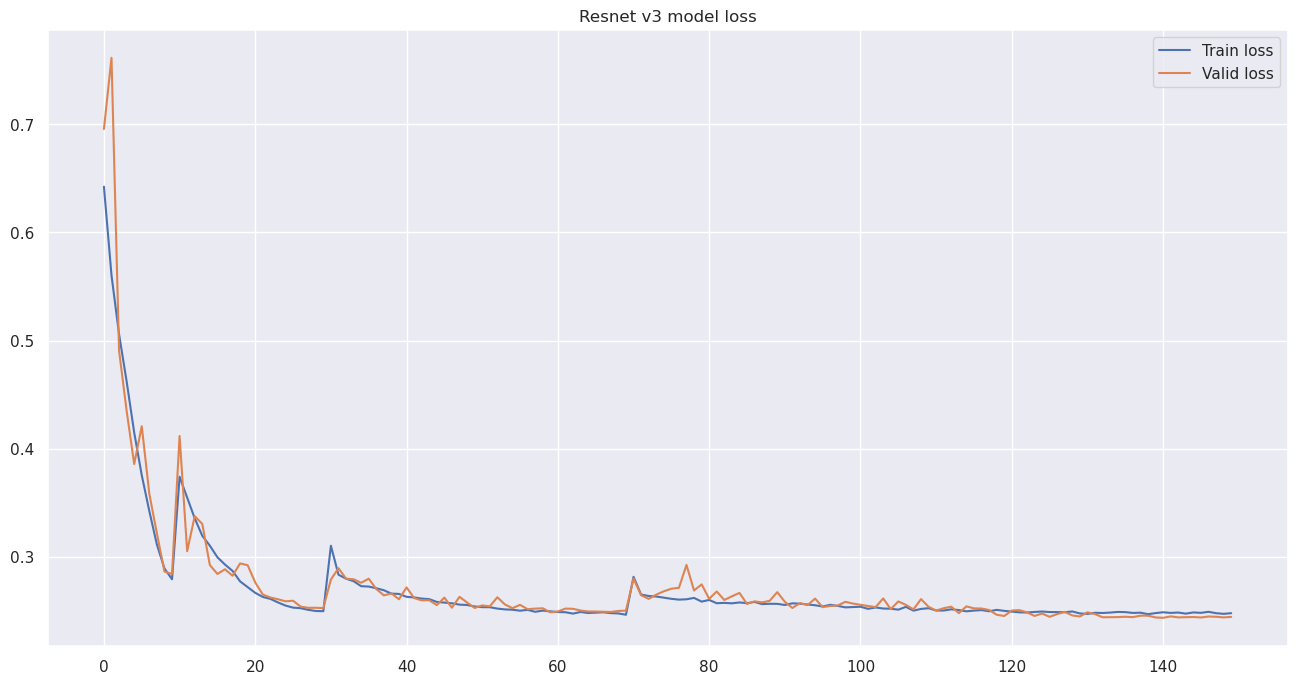

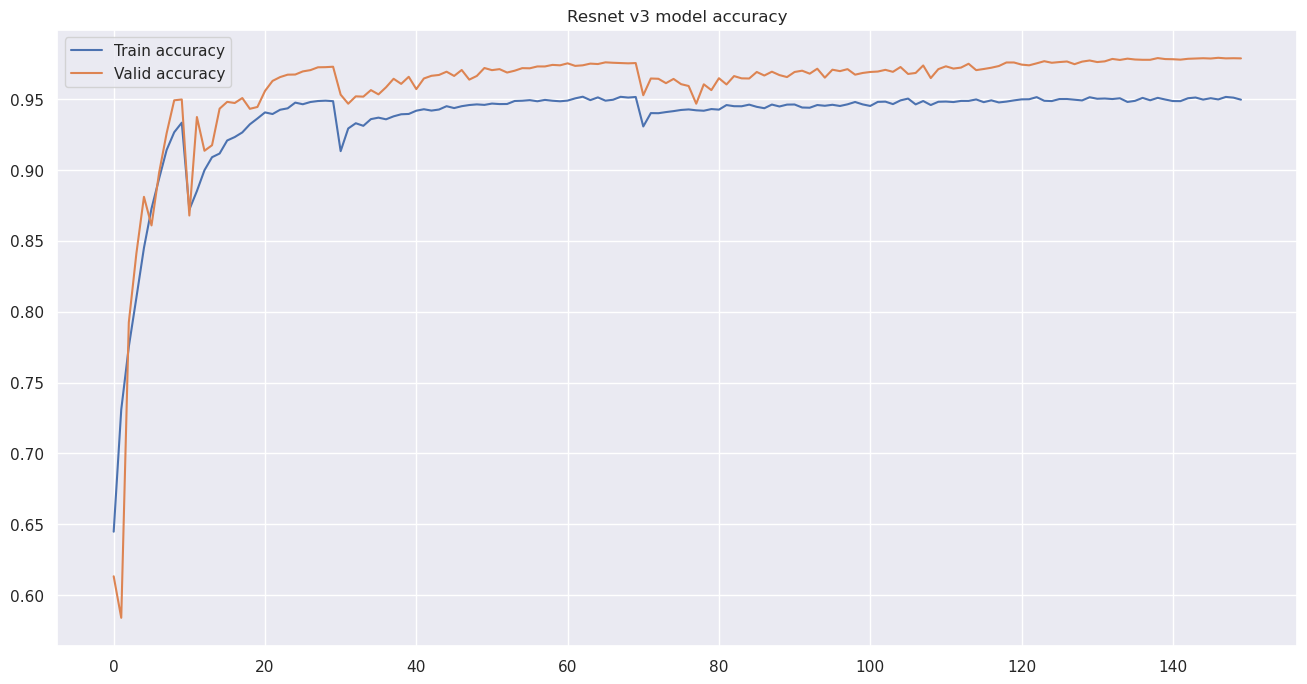

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

import torch
import gc

gc.collect()
torch.cuda.empty_cache() # (очистка кеша) добавил так как видео карта просила пощады

model = resnet34(num_classes=2).to(device)
opt = AdamW(model.parameters(), lr=1e-3)
scheduler = CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2)

loss = nn.CrossEntropyLoss(label_smoothing=0.1) # взял кроссэнтропию так как это база

fit(model, train_loader, val_loader, opt, scheduler, loss, device, 150, 'Resnet v3 model')

Это моя самая лучшая попытка, resnet получился хороший, скорее всего и нужно было дальше в его сторону копать и тестировать, но я решил попробовать другие архитектурки

#### resnet34 v5

Здесь разница лишь в том, что я поменял аугментацию с resnet - основная на resnet - дополнительная, чтобы протестировать его с mediumblur

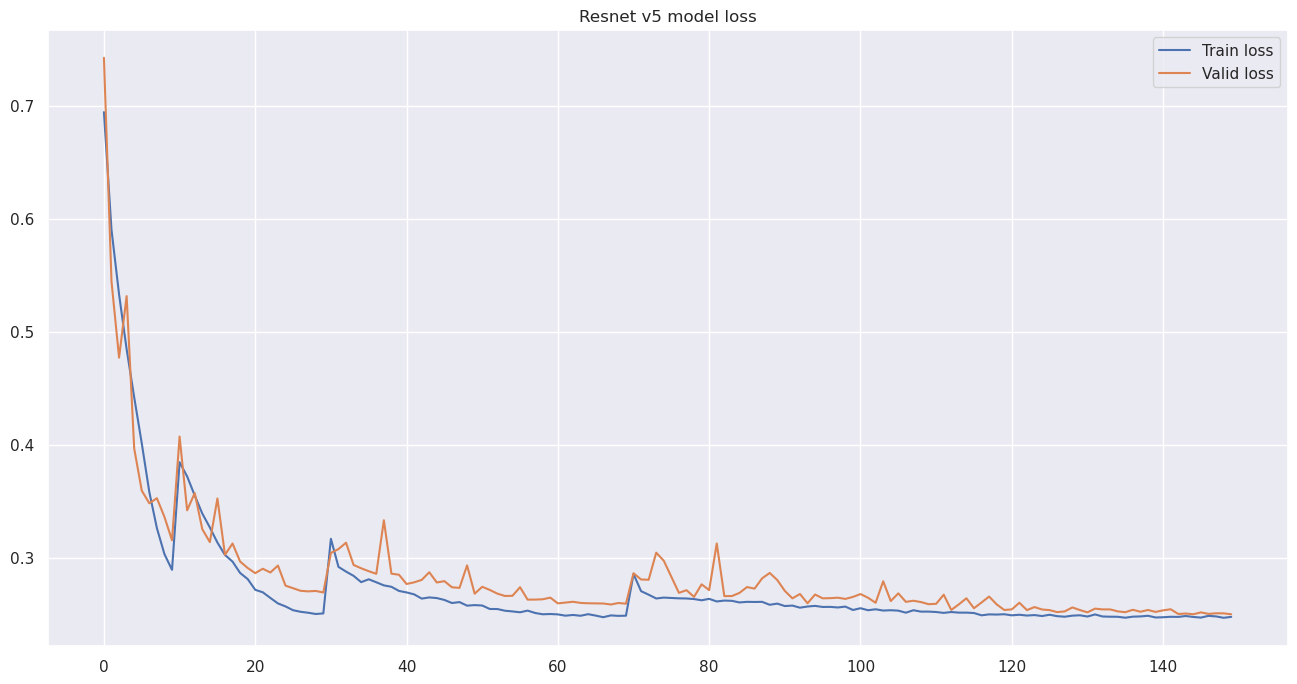

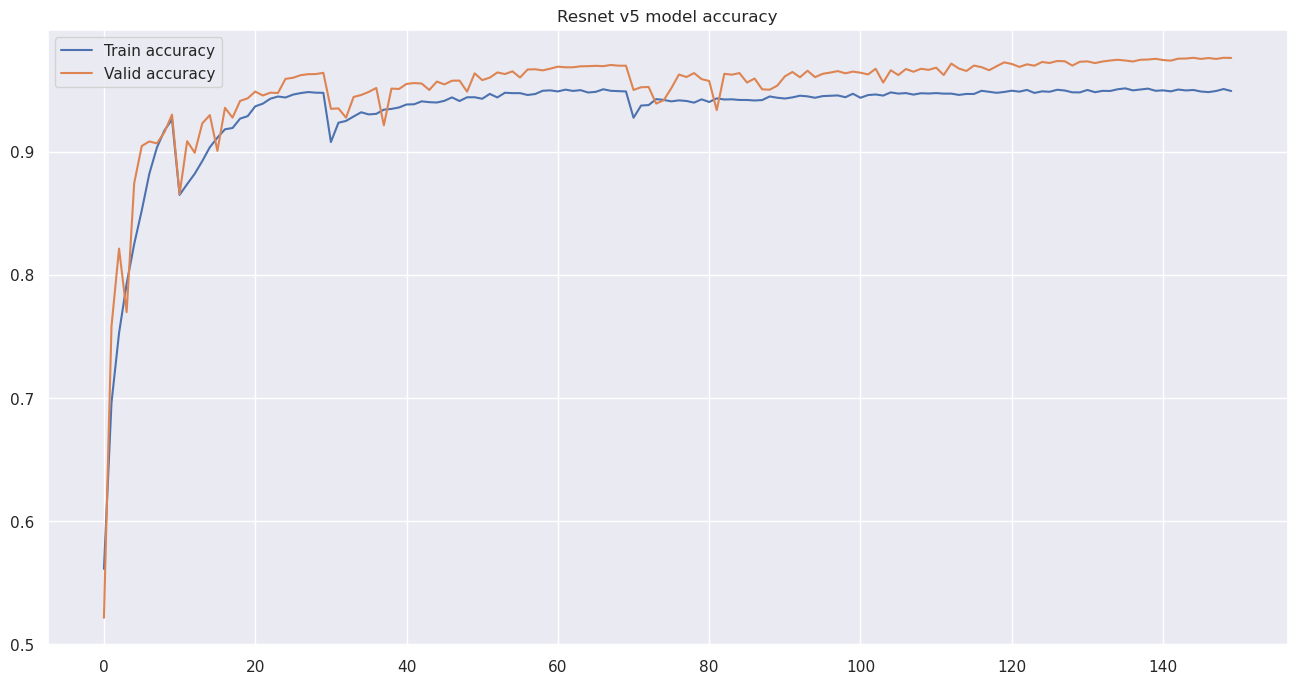

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

import torch
import gc

gc.collect()
torch.cuda.empty_cache() # (очистка кеша) добавил так как видео карта просила пощады

model = resnet34(num_classes=2).to(device)
opt = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2)

loss = nn.CrossEntropyLoss(label_smoothing=0.1) # взял кроссэнтропию так как это база

fit(model, train_loader, val_loader, opt, scheduler, loss, device, 150, 'Resnet v5 model', "checkpoints1")

он показал себя тоже достойно, но хуже предыдущего

## Модель 2 Resnet50

### Причина выбора

resnet34 показал себя отлично, я надеялся он лучше себя покажет из-за другой архитектуры блока

### resnet50 v1

а так использовал абсолютно те же параметры что и в resnet34

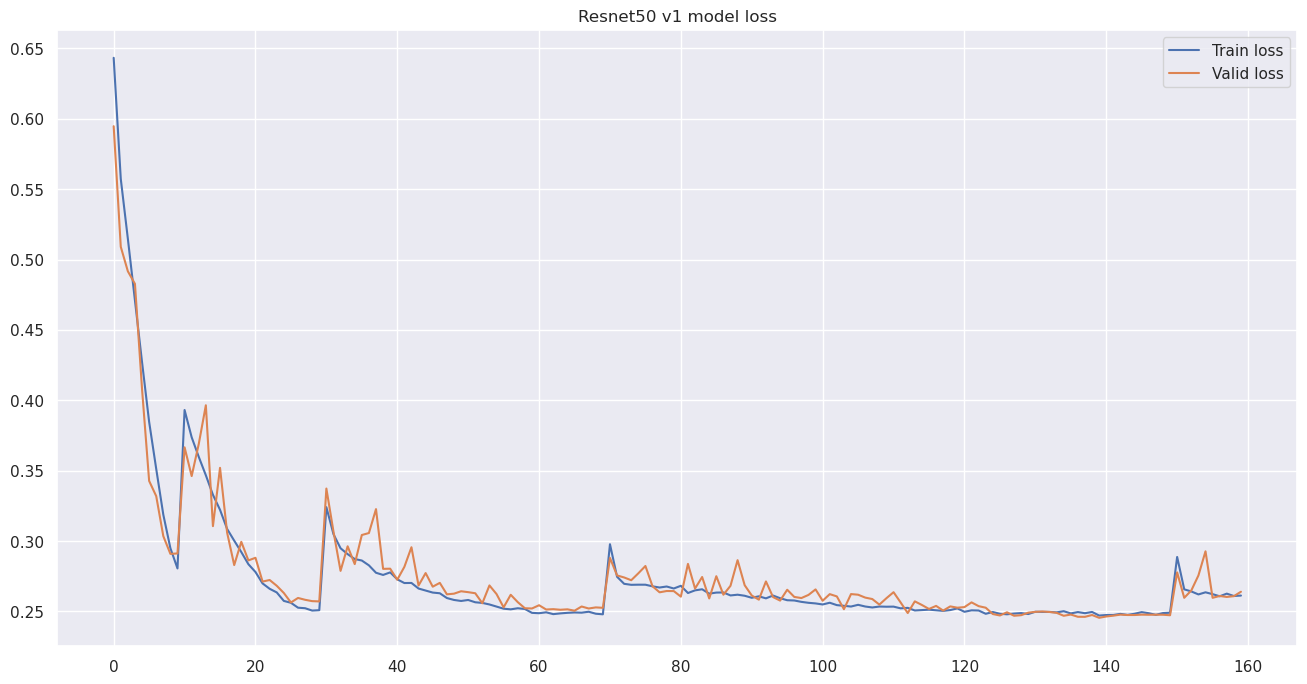

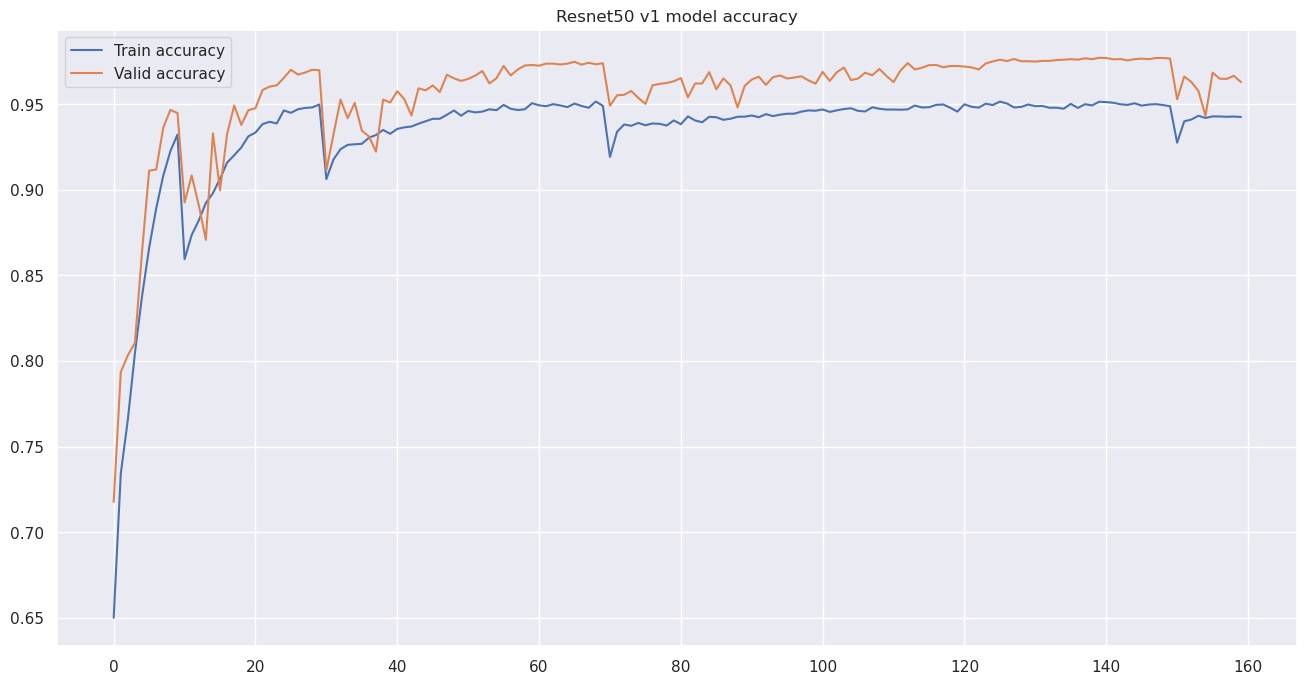

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

import torch
import gc

gc.collect()
torch.cuda.empty_cache() # (очистка кеша) добавил так как видео карта просила пощады

model = resnet50(num_classes=2).to(device)
opt = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2)

loss = nn.CrossEntropyLoss(label_smoothing=0.1) # взял кроссэнтропию так как это база

fit(model, train_loader, val_loader, opt, scheduler, loss, device, 150, 'Resnet50 v1 model', "checkpoints2")

он показал чуть хуже себя, да и я нечайно его поставил на 160 эпох вместо 150

больше экспериментировать с resnet не стал, подумал, что выбил из него всё, хотя сейчас думаю, что нужно было его ещё помучать

## Модель 3 (0.96 score) Convnext nano

### Причина выбора

хотел найти что-то похожее на resnet это тем и оказалось, также как писал выше новая архитектура и вызывала огромные надежды

### Обучение

#### convnext v2

начинается со второй, так как график я удалил случайно, а так по сути он ничем не отличается от этого, только я depth поднял до 3-ёх, чтобы переобучение побороть

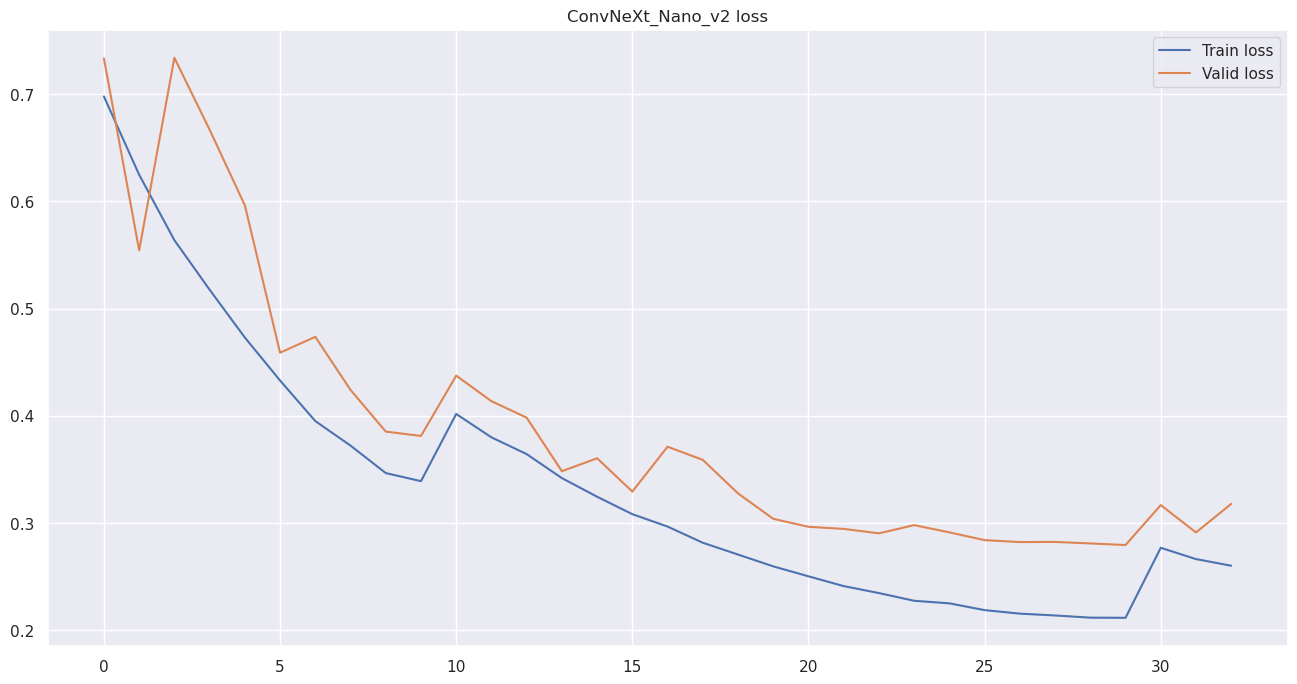

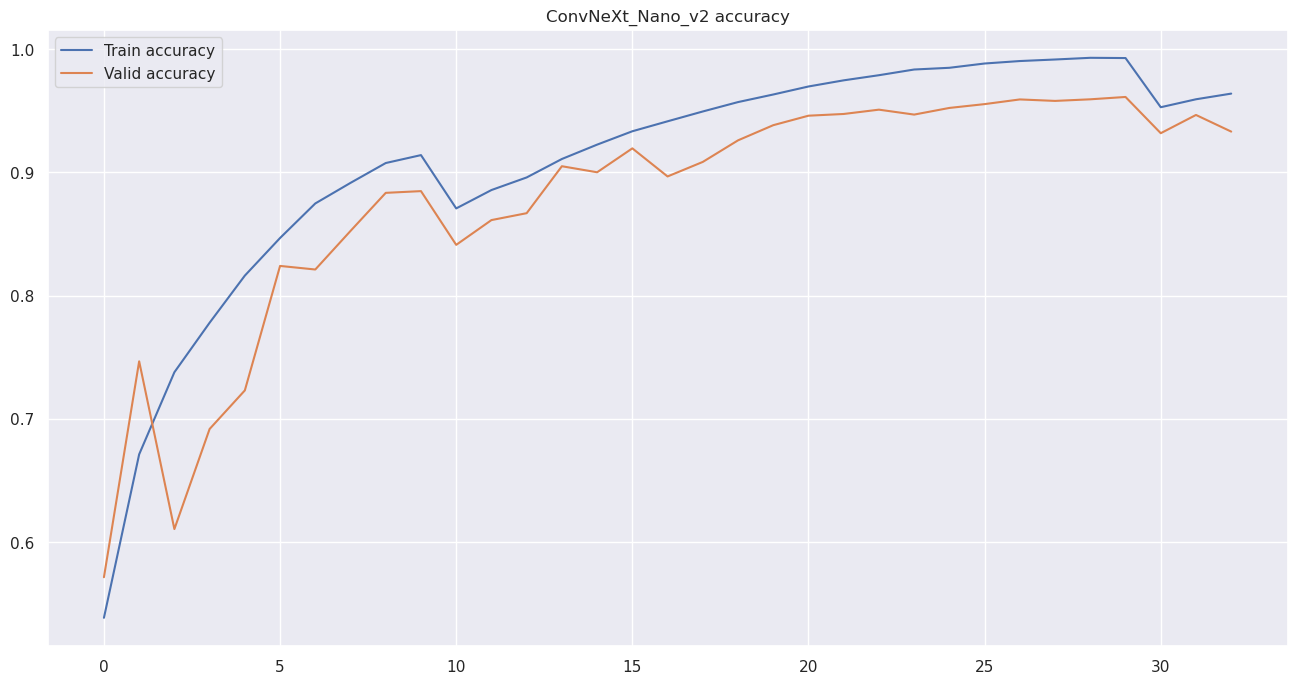

 22%|██▏       | 278/1250 [03:14<11:18,  1.43it/s]


KeyboardInterrupt: 

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

model = convnext_nano(num_classes=2, stochastic_depth_prob=0.3).to(device)

opt = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

scheduler = CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)


fit(model,
    train_loader,
    val_loader,
    opt,
    scheduler,
    loss_fn,
    device,
    150,
    title='ConvNeXt_Nano_v2',
    save_path="checkpoints_convnext"
)

как мы видим переобучение никуда не исчезло, поэтому остановил

#### convnext v3

Здесь я наконец-то начал эксперементировать, добавил аугментацию более жёсткую (convnext - жесткая аугментация), раньше стояла с resnet

тут был использован отдельный scheduler для прогрева AdamW (также использовал отдельную функцию fit, так как тогда не знал о специальных schedulerов, которые объединяют в себе варм ап и основной цил обучения)

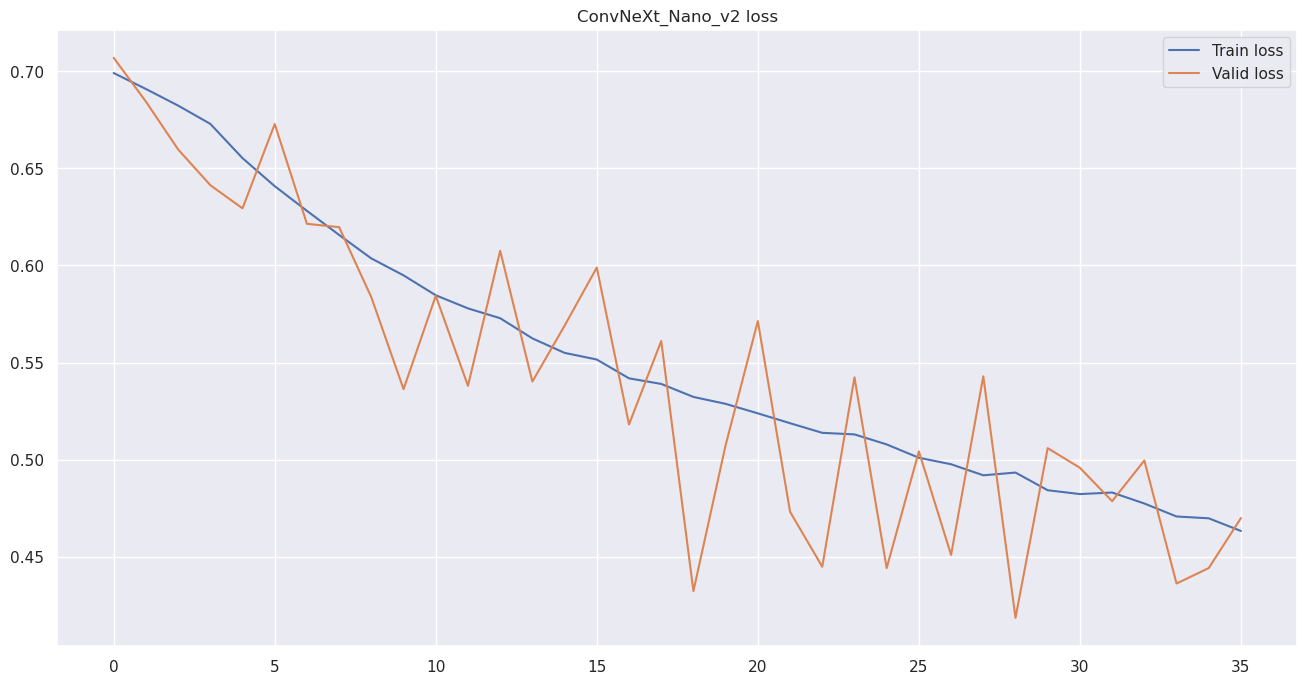

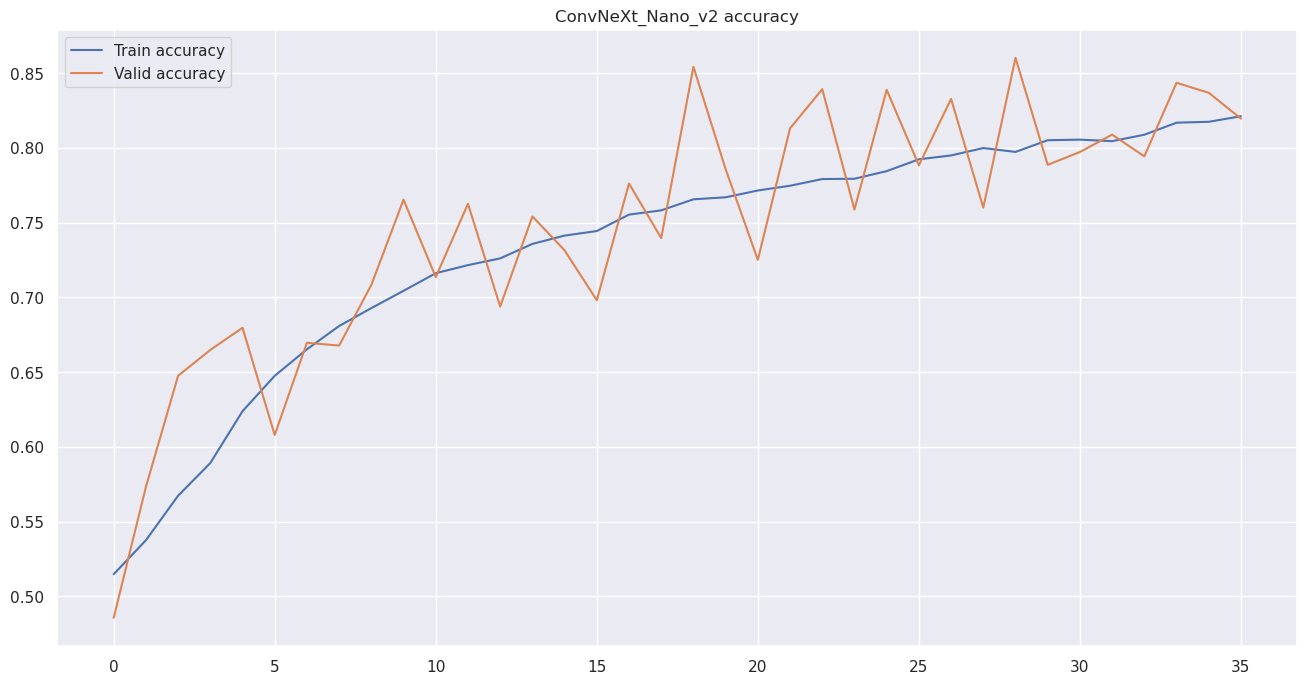

 85%|████████▍ | 1058/1250 [15:35<02:49,  1.13it/s]


KeyboardInterrupt: 

In [ ]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)


fit(model,
    train_loader,
    val_loader,
    opt,
    warmup_scheduler,
    cosine_scheduler,
    loss_fn,
    device,
    70,
    title='ConvNeXt_Nano_v2',
    save_path="checkpoints_convnext"
)

тогда подумал, что идёт слишком медленно, поэтому, хотя сейчас скажу что обучение шло довольно хорошо

#### convnext v4

тут я уже использовал OneCycleLR, как раз сочетает в себе warp up и обычный цикл

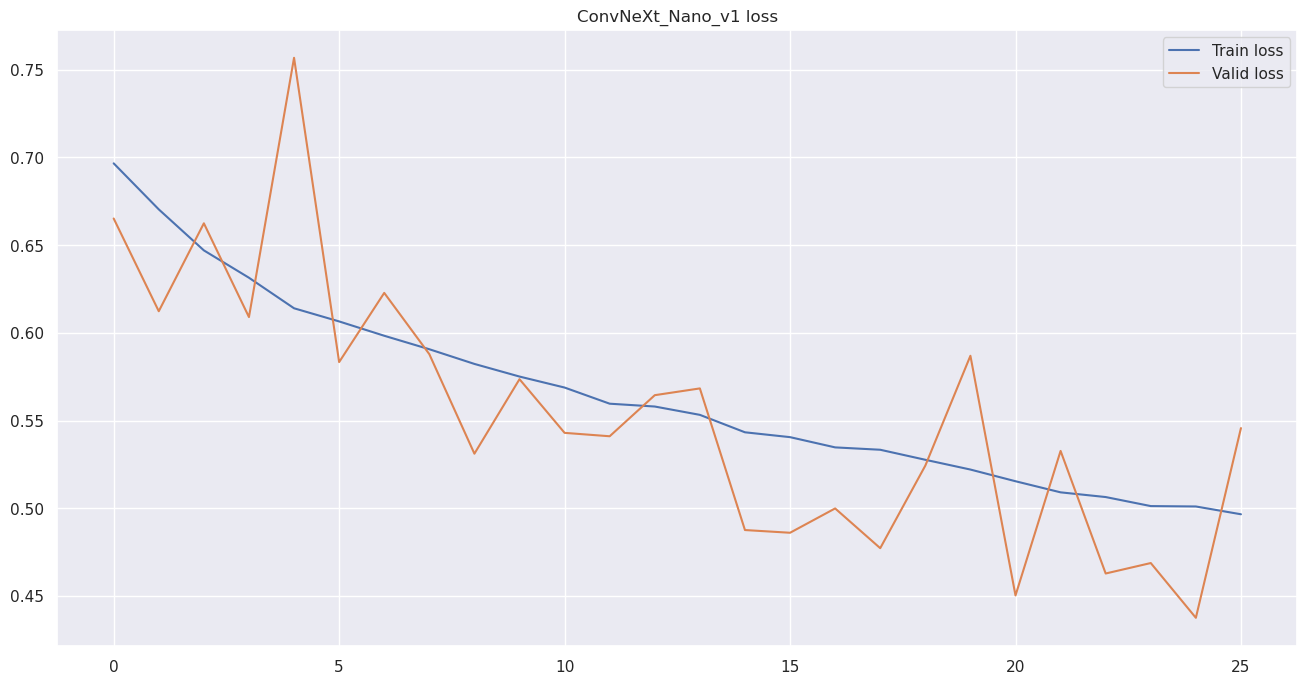

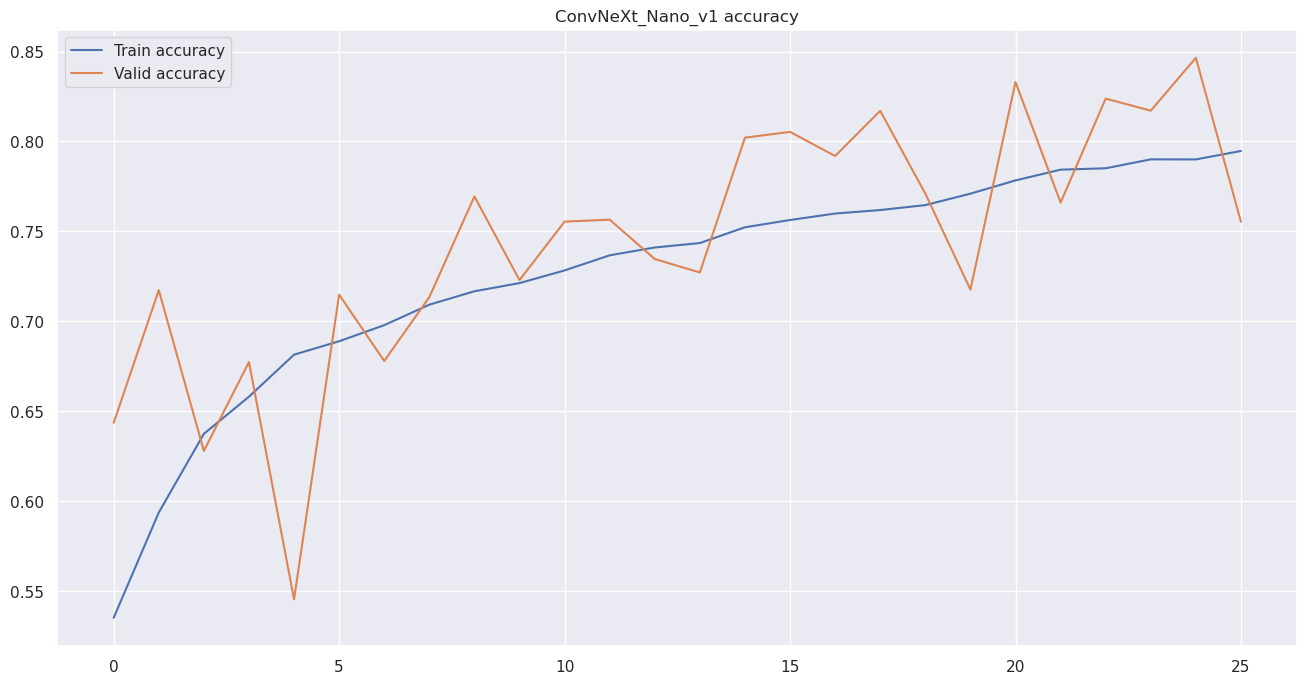

 46%|████▌     | 576/1250 [06:11<07:14,  1.55it/s]


KeyboardInterrupt: 

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

model = convnext_nano(num_classes=2, stochastic_depth_prob=0.2).to(device)

opt = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)

scheduler = OneCycleLR(
    opt,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=70,
    pct_start=0.2,
    anneal_strategy='cos',
    final_div_factor=100.0
)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)


fit(
    model,
    train_loader,
    val_loader,
    opt,
    scheduler,
    loss_fn,
    device,
    70,
    title='ConvNeXt_Nano_v1',
    save_path="checkpoints_convnext"
)

остановил по той же причине что и предыдущий, так как не поверил в него

#### convnext v5

решил вернуться к CosineAnnealingWarmRestarts чтобы протестировать гиперпараметры, которые я немного изменял для предыдущих версий обучения

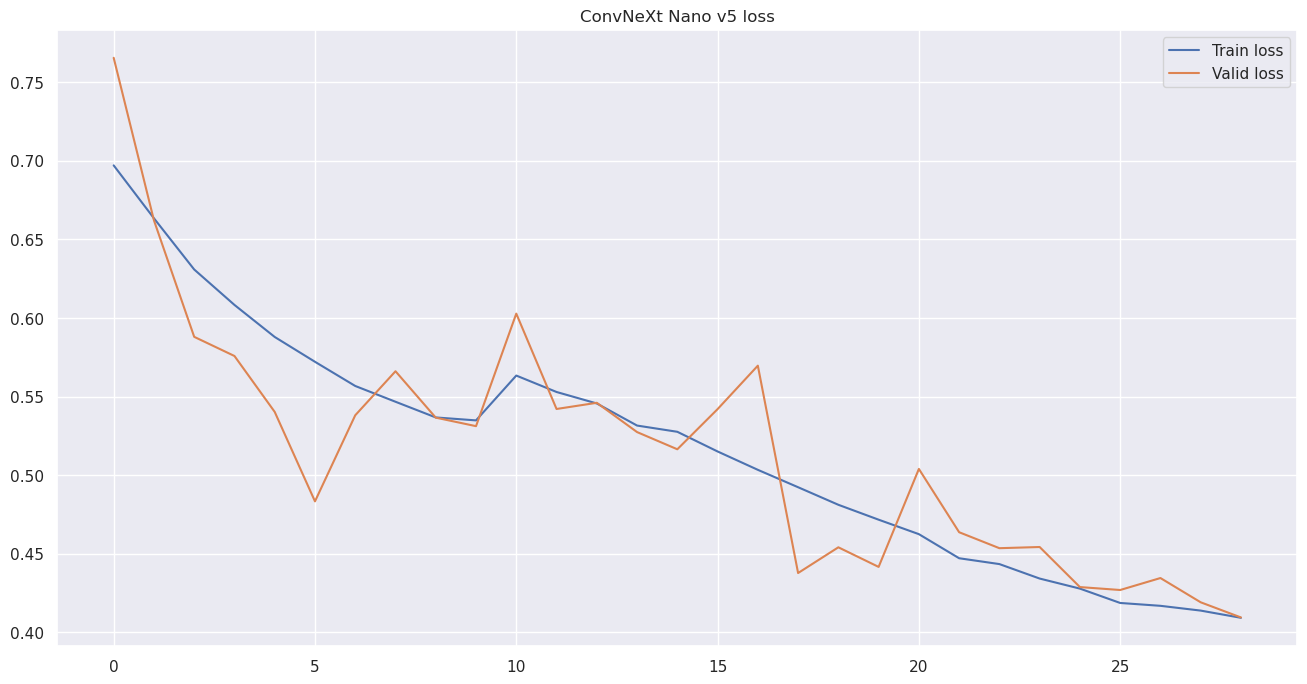

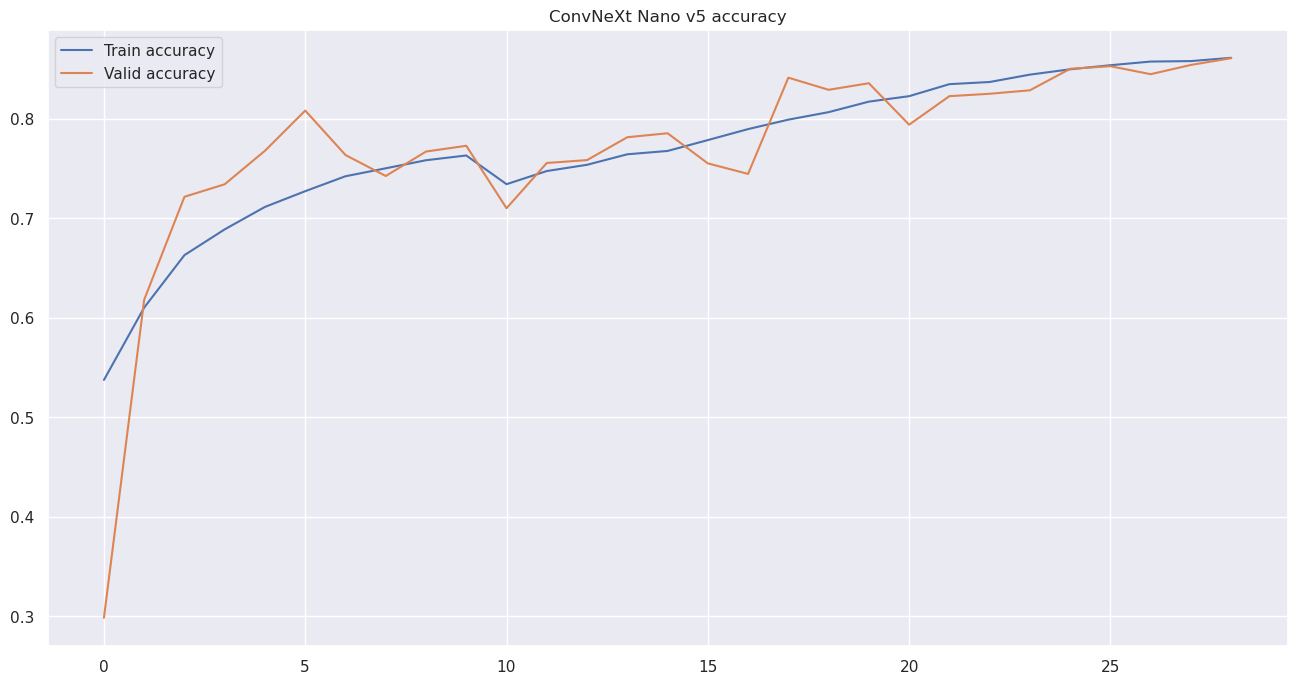

 21%|██        | 263/1250 [03:20<12:33,  1.31it/s]


KeyboardInterrupt: 

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

model = convnext_nano(num_classes=2, stochastic_depth_prob=0.2).to(device)

opt = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)

scheduler = CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)


fit(model,
    train_loader,
    val_loader,
    opt,
    scheduler,
    loss_fn,
    device,
    150,
    title='ConvNeXt Nano v5',
    save_path="checkpoints_convnext"
)

я понял, что параметры слишком жёстко били по convnext, поэтому остановил обучение

#### convnext v6

просто решил вернуться к самым первым параметрам, но с другой аугментацией

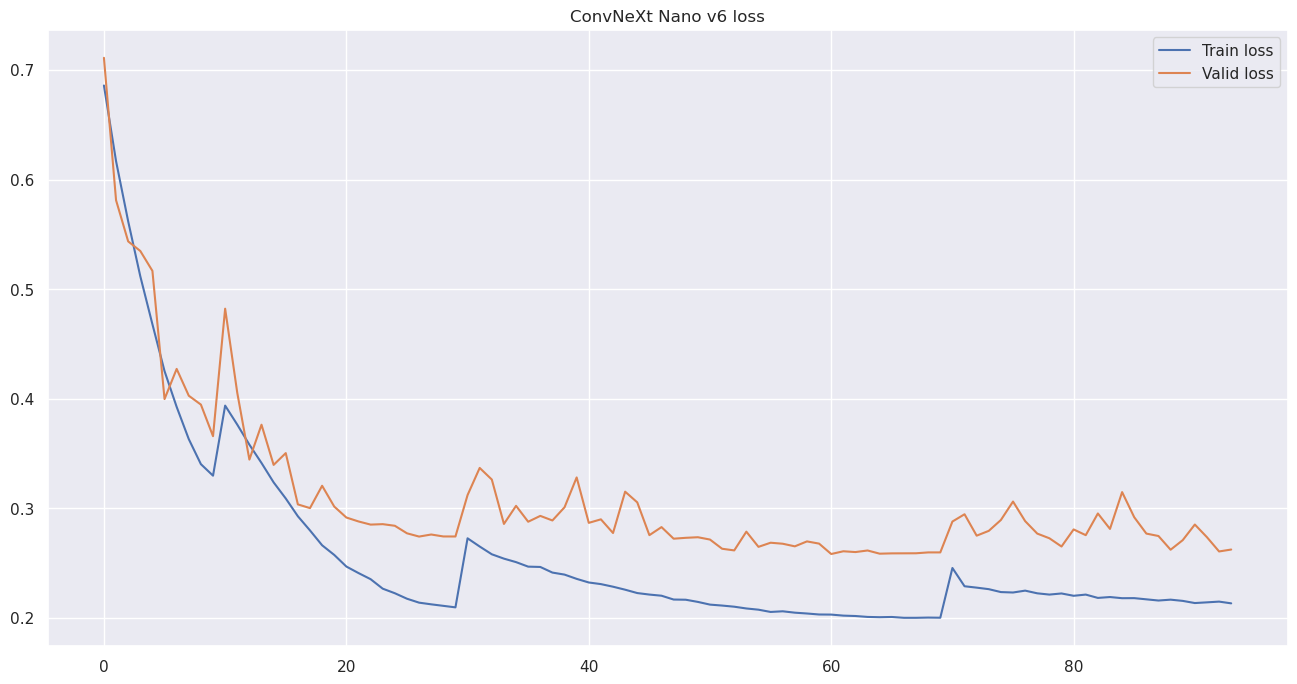

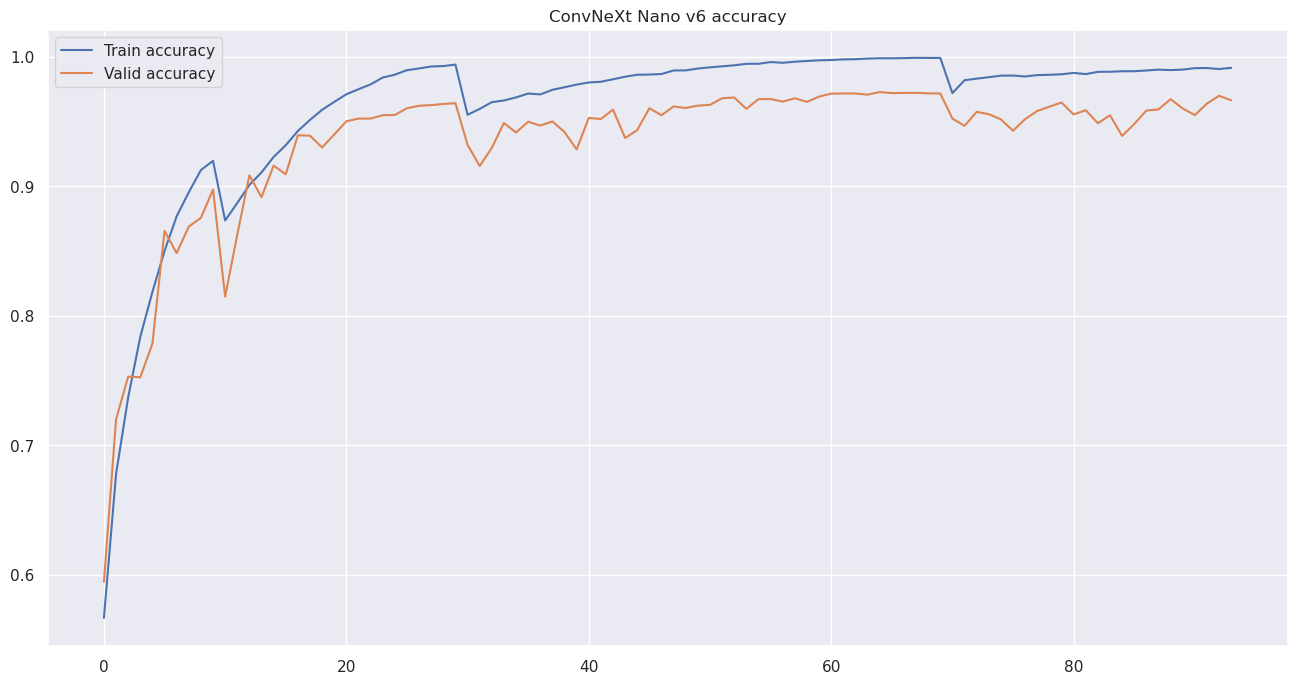

 64%|██████▍   | 803/1250 [08:55<04:58,  1.50it/s]


KeyboardInterrupt: 

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

model = convnext_nano(num_classes=2, stochastic_depth_prob=0.2).to(device)

opt = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

scheduler = CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)


fit(model,
    train_loader,
    val_loader,
    opt,
    scheduler,
    loss_fn,
    device,
    70,
    title='ConvNeXt Nano v6',
    save_path="checkpoints_convnext"
)

остановил, ттак как оно переобучилось

#### convnext v7

решил взять более подходящие гиперпараметры для scheduler, так как 10 эпох на начальное обучение не хватало

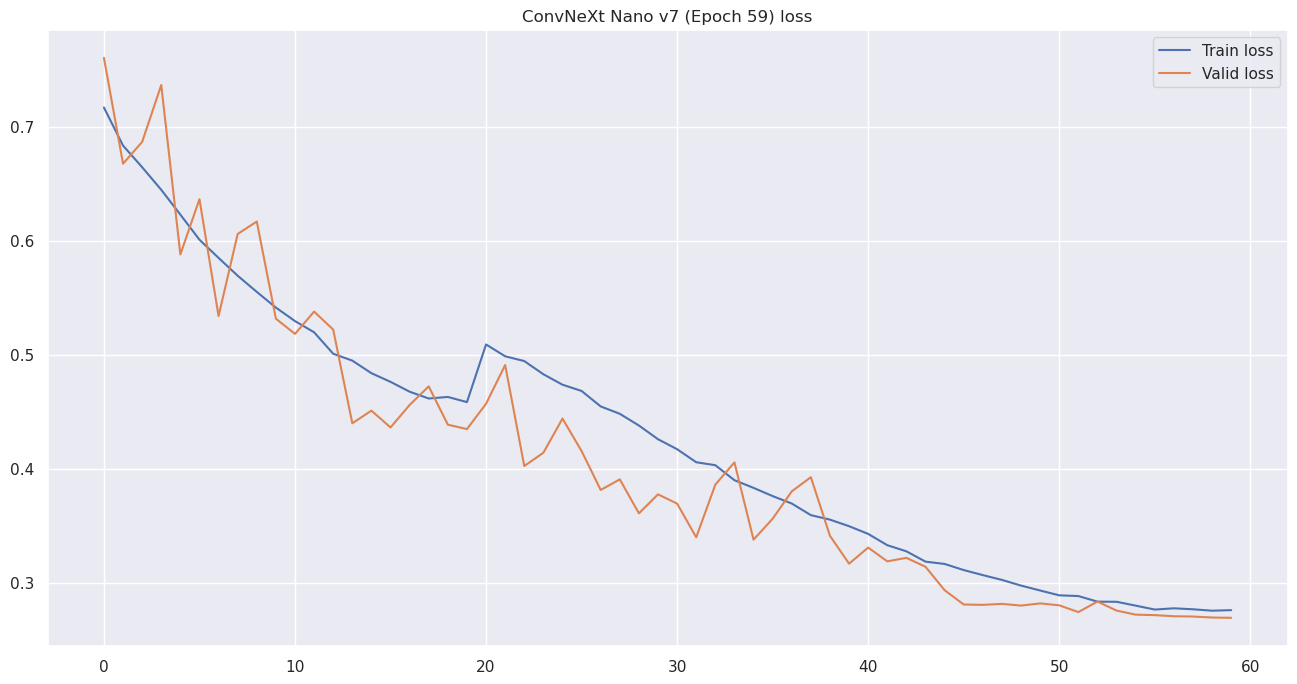

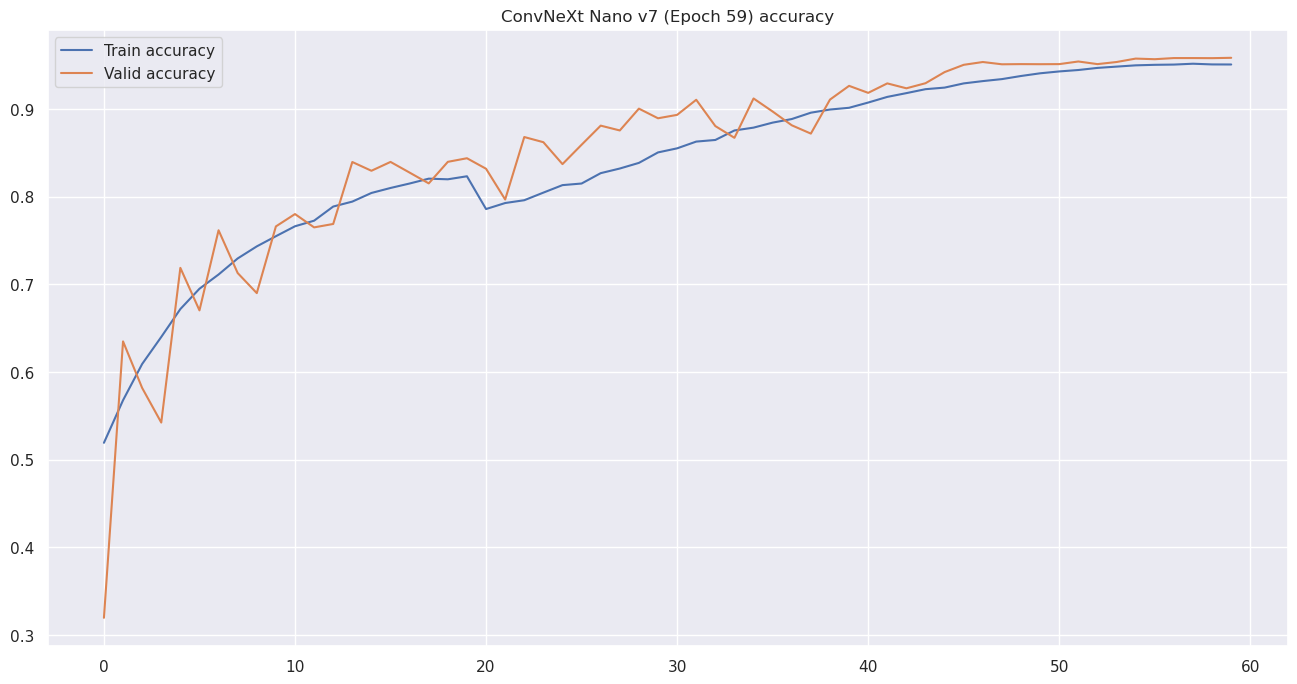

([0.7168103978157043,
  0.6834254265785217,
  0.664463048028946,
  0.6446463138103485,
  0.6228852452039718,
  0.6008617230415344,
  0.584920873618126,
  0.5692748278617858,
  0.5551039321899414,
  0.5413422154664993,
  0.5294914853811264,
  0.5196758749961853,
  0.5008461505174637,
  0.49482794542312625,
  0.48379413828849793,
  0.47619566452503204,
  0.46754887282848356,
  0.4615771729230881,
  0.4629523624420166,
  0.4584190815210342,
  0.5090059798479081,
  0.4986152732372284,
  0.49443015627861026,
  0.4828648553609848,
  0.47368841807842255,
  0.46821483047008516,
  0.45463581013679505,
  0.44816106657981875,
  0.43789671940803526,
  0.42586887642145155,
  0.41710106546878817,
  0.40567475914955137,
  0.4030741289973259,
  0.3899146703839302,
  0.3831957020998001,
  0.37598564825057984,
  0.3694614153623581,
  0.35927823736667636,
  0.355332256090641,
  0.3495804885268211,
  0.3428175016760826,
  0.3329266828417778,
  0.3275435364842415,
  0.31849010128974914,
  0.316464009606838

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.amp import GradScaler
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

model = convnext_nano(num_classes=2, stochastic_depth_prob=0.2).to(device)

opt = AdamW(model.parameters(), lr=5e-4, weight_decay=5e-2)

scheduler = CosineAnnealingWarmRestarts(opt, T_0=20, T_mult=2)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

scaler = GradScaler("cuda")

fit(
    model,
    train_loader,
    val_loader,
    opt,
    scheduler,
    loss_fn,
    device,
    60,
    title='ConvNeXt Nano v7',
    save_path="checkpoints_convnext_v7"
)

к сожалению обучилось довольно слабо, поэтому я пришёл к тому что поменял стратегию обучения

#### convnext v8

сначала сделал функцию для дропаута для обучения слоёв по-разному (в итоге так и не использовал её так как у нас не предобученные модельки

In [ ]:
def get_parameter_groups(model, base_lr, weight_decay, layer_decay=0.8):
    """
    Разбивает параметры ConvNeXt на группы с затухающим LR.
    """
    # Количество слоев в ConvNeXt Nano (4 стадии + stem + head)
    # Определяем глубину каждого параметра
    def get_layer_id(name):
        if name.startswith("downsample_layers.0") or name.startswith("stem"):
            return 0
        elif name.startswith("stages.0"):
            return 1
        elif name.startswith("stages.1"):
            return 2
        elif name.startswith("stages.2"):
            return 3
        elif name.startswith("stages.3"):
            return 4
        elif name.startswith("head") or name.startswith("norm"):
            return 5
        return 5

    num_layers = 6
    parameter_groups = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue

        layer_id = get_layer_id(name)
        # Формула: LR слоя = base_lr * (decay ^ (max_layer - current_layer))
        layer_lr = base_lr * (layer_decay ** (num_layers - 1 - layer_id))

        # Оптимизация: убираем weight decay для bias и нормализаций (стандарт статьи)
        cur_wd = 0.0 if (len(param.shape) == 1 or name.endswith(".bias")) else weight_decay

        parameter_groups.append({
            "params": [param],
            "lr": layer_lr,
            "weight_decay": cur_wd,
            "layer_id": layer_id
        })

    return parameter_groups

Решил взять обычный cossineannealing с linear для warm up, и сыграть на долгом обучении, которое я пытался сделать на 3-4 версии обучения

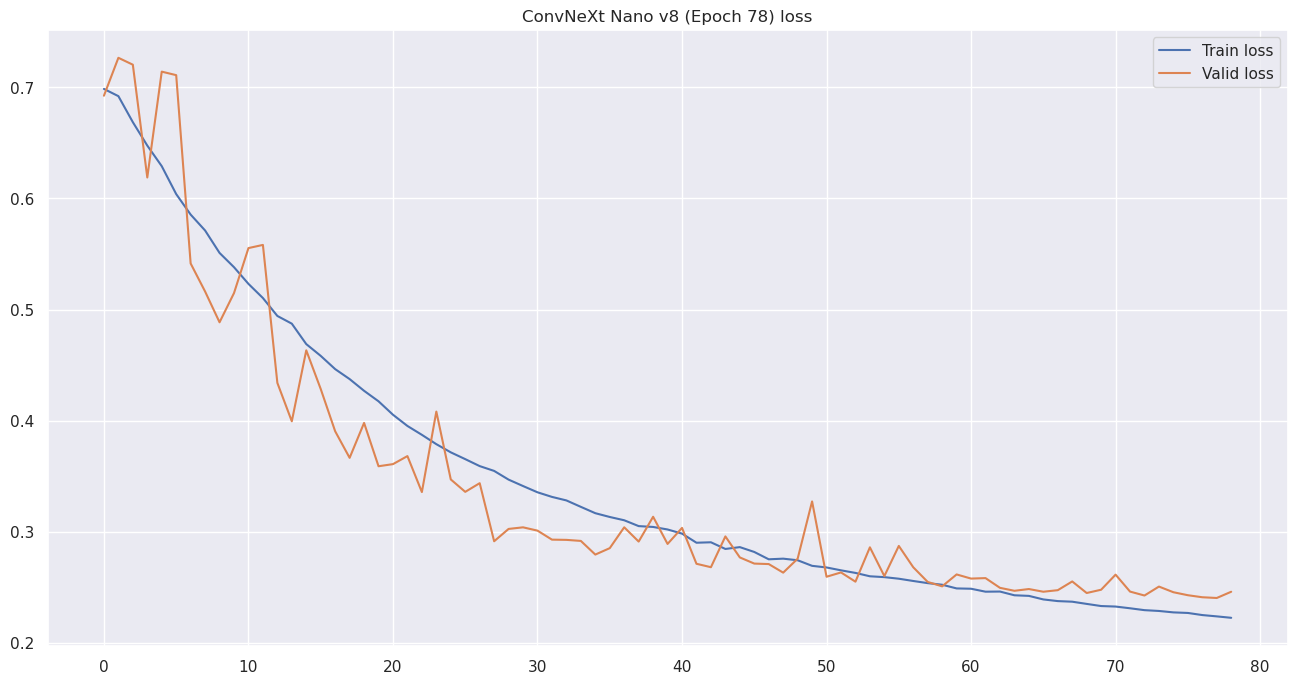

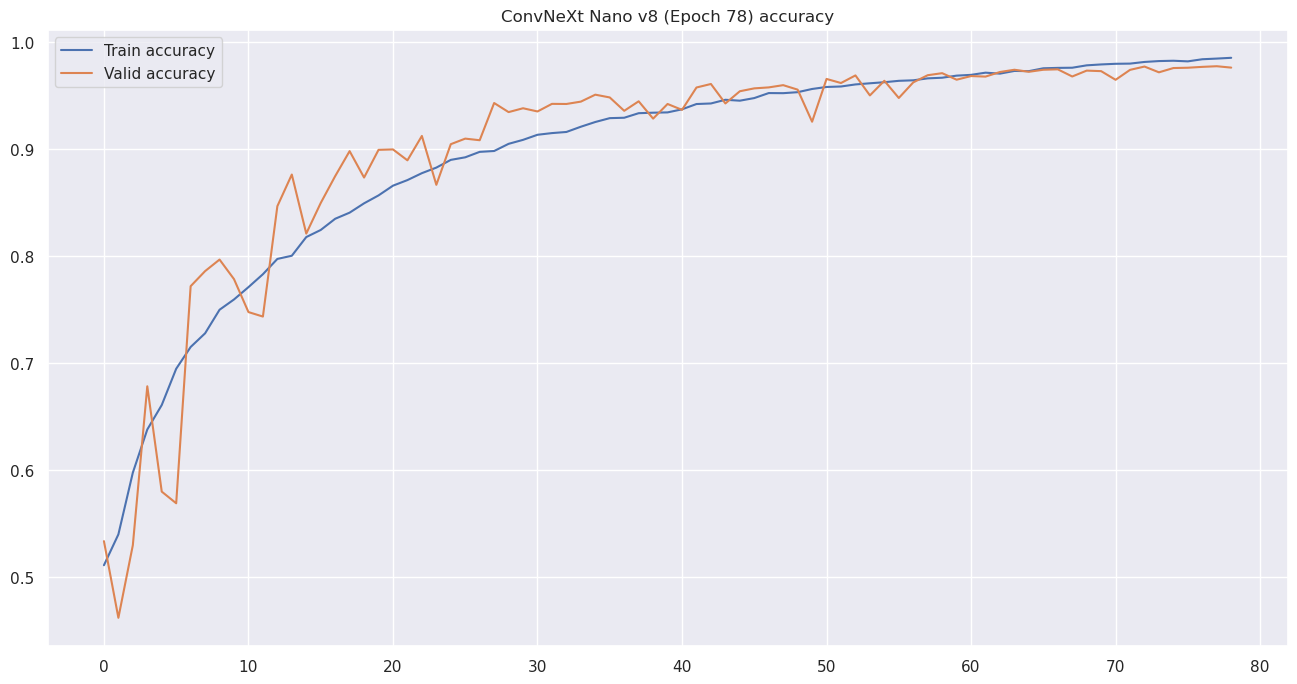

Training part: 37:   3%|▎         | 37/1250 [00:25<14:08,  1.43it/s]


KeyboardInterrupt: 

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.amp import GradScaler
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

model = convnext_nano(num_classes=2, stochastic_depth_prob=0.2).to(device)

base_lr = 1e-3
wd = 5e-2

param_groups = get_parameter_groups(model, base_lr, wd, layer_decay=1.0)

opt = AdamW(param_groups, lr=base_lr)

warmup_epochs = 5
main_epochs = 100

warmup_scheduer = LinearLR(opt, start_factor=0.01, total_iters=warmup_epochs)

cosine_scheduler = CosineAnnealingLR(opt, T_max=main_epochs)

scheduler = SequentialLR(opt, schedulers=[warmup_scheduer, cosine_scheduler], milestones=[warmup_epochs])

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

scaler = GradScaler("cuda")

fit(
    model,
    train_loader,
    val_loader,
    opt,
    scheduler,
    loss_fn,
    device,
    warmup_epochs + main_epochs,
    title='ConvNeXt Nano v8',
    save_path="checkpoints_convnext_v8"
)

к сожалению, нне смог до конца обучить, так как сгорел блок питания, но эти параметры доказали свою эффективность и на их основе будут разработаны параметры efficientnet, который наберёт наш наибольший score

## Модель 4 Regnet Y 400

### Обучение

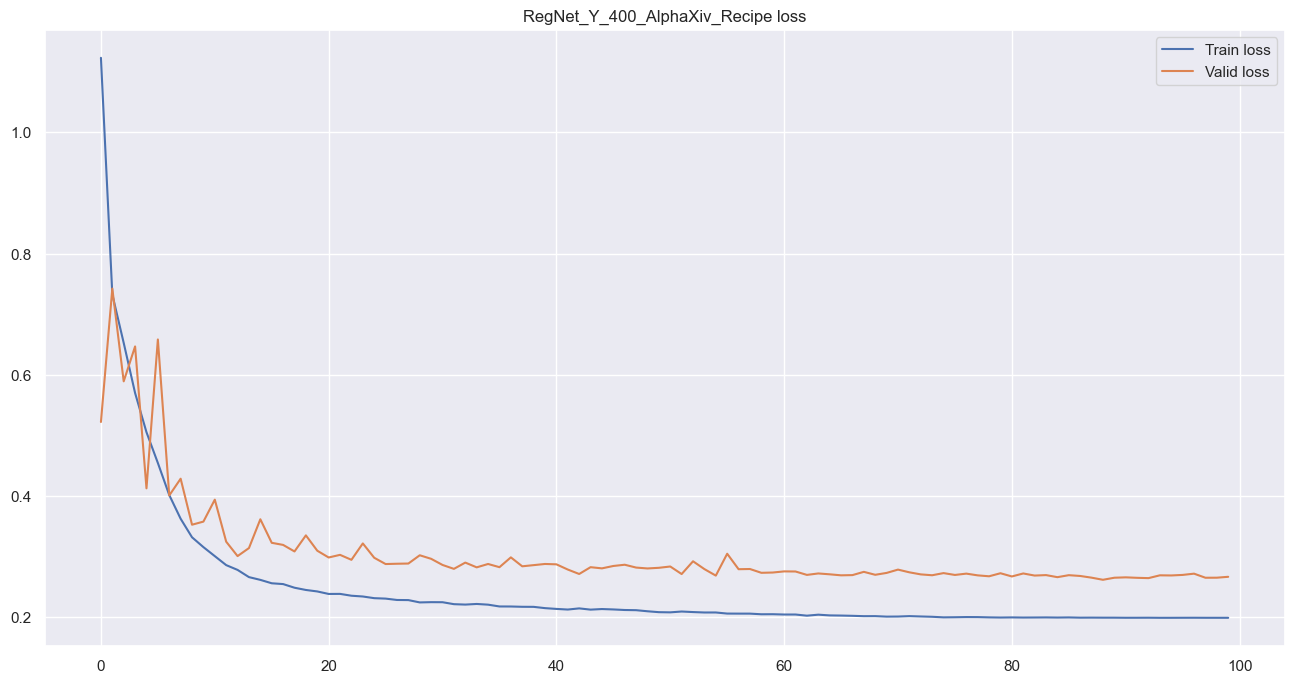

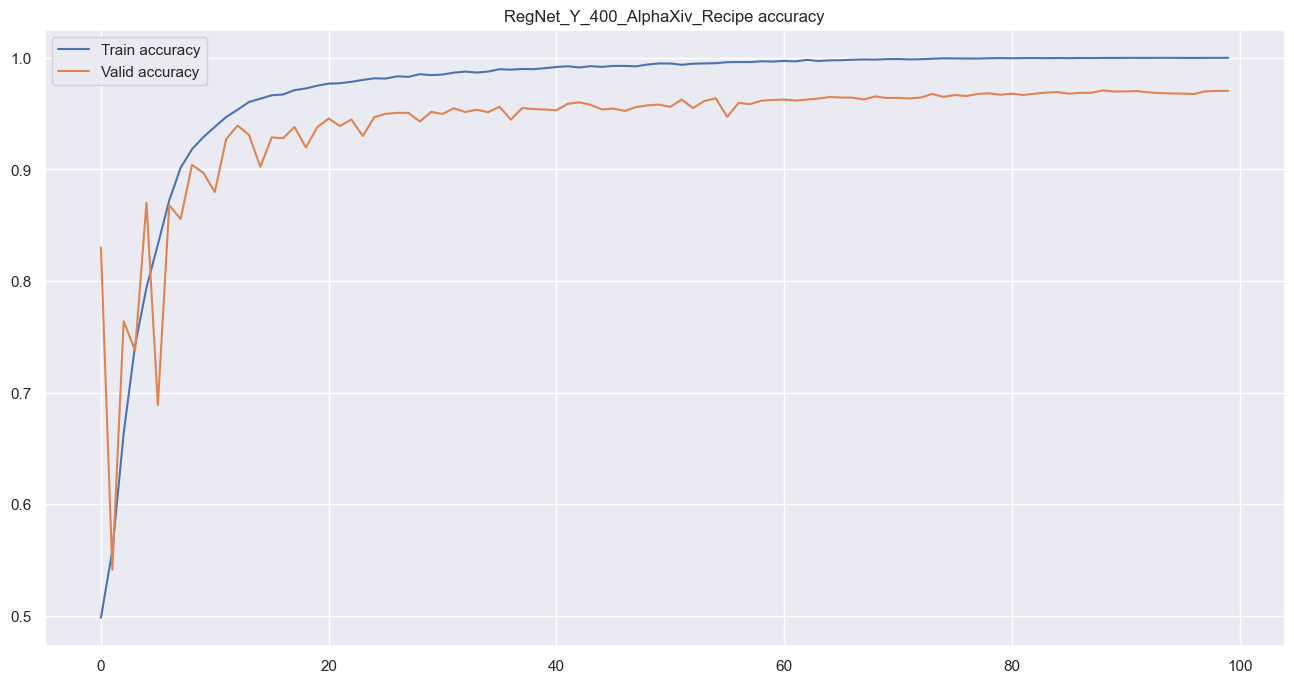

In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, SequentialLR, LinearLR

# 1. Модель (с нуля, 2 класса)
model_regnet = regnet_y_400mf(num_classes=2).to(device)

# 2. Оптимизатор по рецепту AlphaXiv
# LR ставим 1e-3, Weight Decay — 0.05
opt = AdamW(model_regnet.parameters(), lr=1e-3, weight_decay=0.05, betas=(0.9, 0.999))

# 3. Настройка сложного шедулера с Warmup (Разогрев 5 эпох + Косинус)
num_epochs = 100
warmup_epochs = 5

scheduler_warmup = LinearLR(opt, start_factor=0.001, end_factor=1.0, total_iters=warmup_epochs)
scheduler_cosine = CosineAnnealingLR(opt, T_max=num_epochs - warmup_epochs)

# Собираем их в один, чтобы в fit просто вызывать scheduler.step()
scheduler = SequentialLR(opt, schedulers=[scheduler_warmup, scheduler_cosine], milestones=[warmup_epochs])

# 4. Лосс с Label Smoothing
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

# ЗАПУСК
fit(
    model_regnet,
    train_loader,
    val_loader,
    opt,
    scheduler,
    loss_fn,
    device,
    num_epochs,
    "RegNet_Y_400_AlphaXiv_Recipe"
)

## Модель 5 EnfficientNet B0


немного изменила функцию evaluate так как модель при обучении зависала

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


@torch.inference_mode()
def evaluate_for_enf(model, data_loader, loss_fn, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in data_loader:  #убрали tqdm полностью
            x, y = x.to(device), y.to(device).long()
            output = model(x)
            loss = loss_fn(output, y)

            total_loss += loss.item() * x.size(0)
            _, predicted = torch.max(output, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [ ]:
from IPython.display import clear_output


def fit_enf(model, train_loader, valid_loader, optimizer, loss_fn, device, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)
    for epoch in range(num_epochs):
        train_loss, train_accuracy = run_epoch(model, optimizer, loss_fn, train_loader, device)
        valid_loss, valid_accuracy = evaluate_for_enf(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            title
        )

        torch.save(model.state_dict(), f"checkpoints/model_{epoch}.pt")
        torch.save(optimizer.state_dict(), f"checkpoints/optimizer_{epoch}.pt")

        scheduler.step(valid_loss)


def fit_enf(model, train_loader, valid_loader, optimizer, scheduler, loss_fn, device, num_epochs, title, save_path="checkpoints1"):
    if not os.path.exists(save_path):
        os.makedirs(save_path)
        print(f"📁 Папка '{save_path}' не найдена и была создана.")
    else:
        print(f"✅ Папка '{save_path}' уже существует.")

    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []
    for epoch in range(num_epochs):
        train_loss, train_accuracy = run_epoch(model, optimizer, loss_fn, train_loader, device)
        valid_loss, valid_accuracy = evaluate_for_enf(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            title
        )

        if scheduler:
            scheduler.step()

        torch.save(model.state_dict(), f"{save_path}/model_{epoch}.pt")
        torch.save(optimizer.state_dict(), f"{save_path}/optimizer_{epoch}.pt")

реализация архитектуры EnfficientNet

(отталкивалась от статьи https://arxiv.org/abs/1905.11946)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SqueezeExcitation(nn.Module):
  #модуль squeeze-exitation для калибровки каналов
    def __init__(self, in_channels, reduced_dim):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, reduced_dim, 1),
            nn.SiLU(),
            nn.Conv2d(reduced_dim, in_channels, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.se(x) #карты признаков на веса каналов

class MBConv(nn.Module):
   #инвертированный bottleneck c depthwise convolution
    def __init__(self, in_channels, out_channels, kernel_size, stride, expand_ratio, se_ratio=0.25, dropout_rate=0.2):
        super().__init__()
        self.stride = stride
        self.use_residual = stride == 1 and in_channels == out_channels #чтобы скип конекшн был только при совпадении размеров
        expanded_channels = in_channels * expand_ratio #расширение каналов

        layers = []

        if expand_ratio != 1:
            layers.append(nn.Conv2d(in_channels, expanded_channels, 1, bias=False))
            layers.append(nn.BatchNorm2d(expanded_channels))
            layers.append(nn.SiLU())

        layers.append(nn.Conv2d(expanded_channels, expanded_channels, kernel_size,
                                stride, kernel_size//2, groups=expanded_channels, bias=False))
        layers.append(nn.BatchNorm2d(expanded_channels))
        layers.append(nn.SiLU())

        #Squeeze-and-Excitation
        if se_ratio:
            reduced_dim = max(1, int(in_channels * se_ratio))
            layers.append(SqueezeExcitation(expanded_channels, reduced_dim))

        layers.append(nn.Conv2d(expanded_channels, out_channels, 1, bias=False))
        layers.append(nn.BatchNorm2d(out_channels))

        self.block = nn.Sequential(*layers)
        self.dropout = nn.Dropout2d(dropout_rate) if dropout_rate > 0 else nn.Identity()

    def forward(self, x):
        if self.use_residual:
            return x + self.dropout(self.block(x))
        return self.block(x)

class EfficientNetB0(nn.Module):
    #сама архитектура efficientnet-b0 для классификации изображений
    def __init__(self, num_classes=2, dropout_rate=0.2):
        super().__init__()

        #параметры блоков
        settings = [
            (32, 16, 3, 1, 1, 1),
            (16, 24, 3, 2, 6, 2),
            (24, 40, 5, 2, 6, 2),
            (40, 80, 3, 2, 6, 3),
            (80, 112, 5, 1, 6, 3),
            (112, 192, 5, 2, 6, 4),
            (192, 320, 3, 1, 6, 1),
        ]

        #сверточный слой
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU()
        )

        blocks = []
        for in_ch, out_ch, k, s, e, repeats in settings:
            for i in range(repeats):
                stride = s if i == 0 else 1
                blocks.append(MBConv(in_ch if i == 0 else out_ch, out_ch, k, stride, e, dropout_rate=dropout_rate))

        self.blocks = nn.Sequential(*blocks)

        #классификация
        self.head = nn.Sequential(
            nn.Conv2d(320, 1280, 1, bias=False),
            nn.BatchNorm2d(1280),
            nn.SiLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(1280, num_classes)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.head(x)
        return x


создание модели

In [ ]:
model = EfficientNetB0(num_classes=2, dropout_rate=0.2)
model = model.to(device)

заморозка слоев

In [ ]:
#заморозка сверточной основы (без головы)
for param in model.stem.parameters():
    param.requires_grad = False
for param in model.blocks.parameters():
    param.requires_grad = False

In [ ]:
print(model.head)

in_features = model.head[-1].in_features

model.head = nn.Sequential(
    nn.Conv2d(320, 1280, 1, bias=False),
    nn.BatchNorm2d(1280),
    nn.SiLU(),
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Dropout(0.2),
    nn.Linear(1280, 2)  #2 класса
)

print(model.head)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [ ]:
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

обучение модели

In [ ]:
fit_enf(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    loss_fn,
    device,
    num_epochs=10,
    title="EfficientNet-B0"
)

In [ ]:
for param in model.features.parameters():
    param.requires_grad = True
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

к сожалению, тут без графиков

## Модель 6 Efficientnet B3 v2 (0.973)

### Причина выбора

Мы выбрали EfficientNet-B3, так как это наиболее «умная» архитектура с точки зрения использования вычислительных ресурсов и один из участников команды уже пытался обучать младшую версию

### Обучение

тут получилось с первой попытки сделать высокий скор, просто взяв параметры от convnext

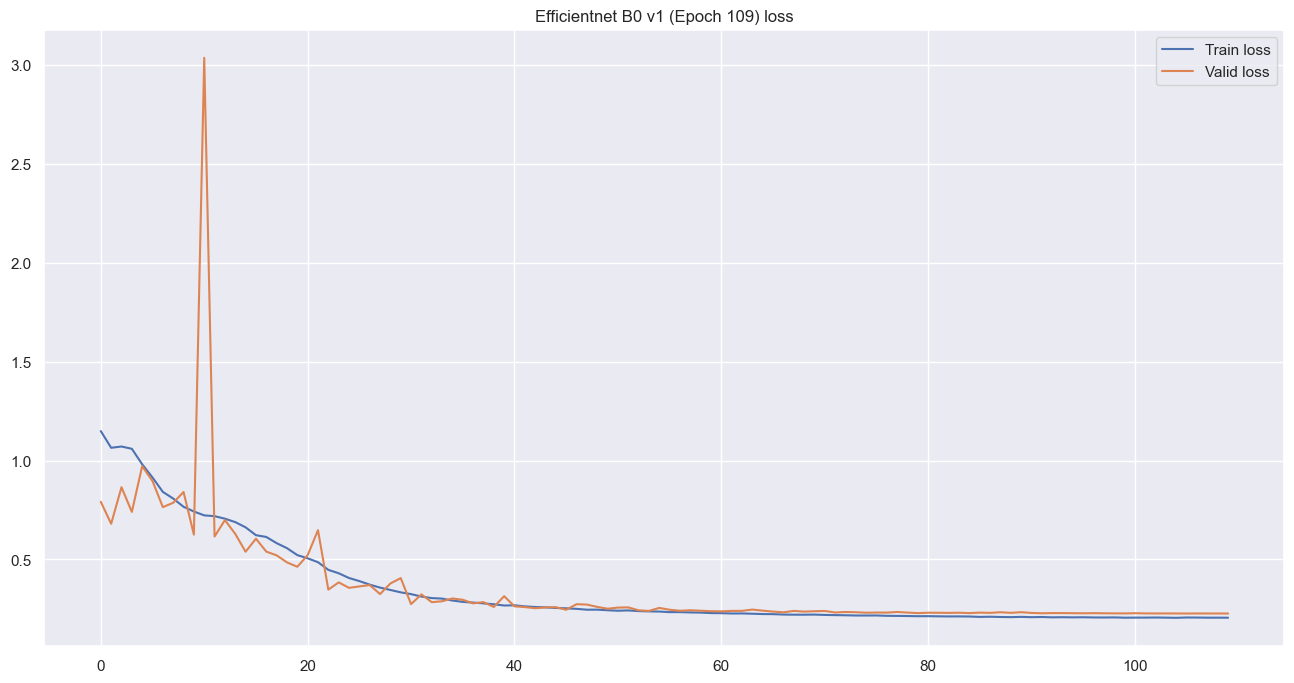

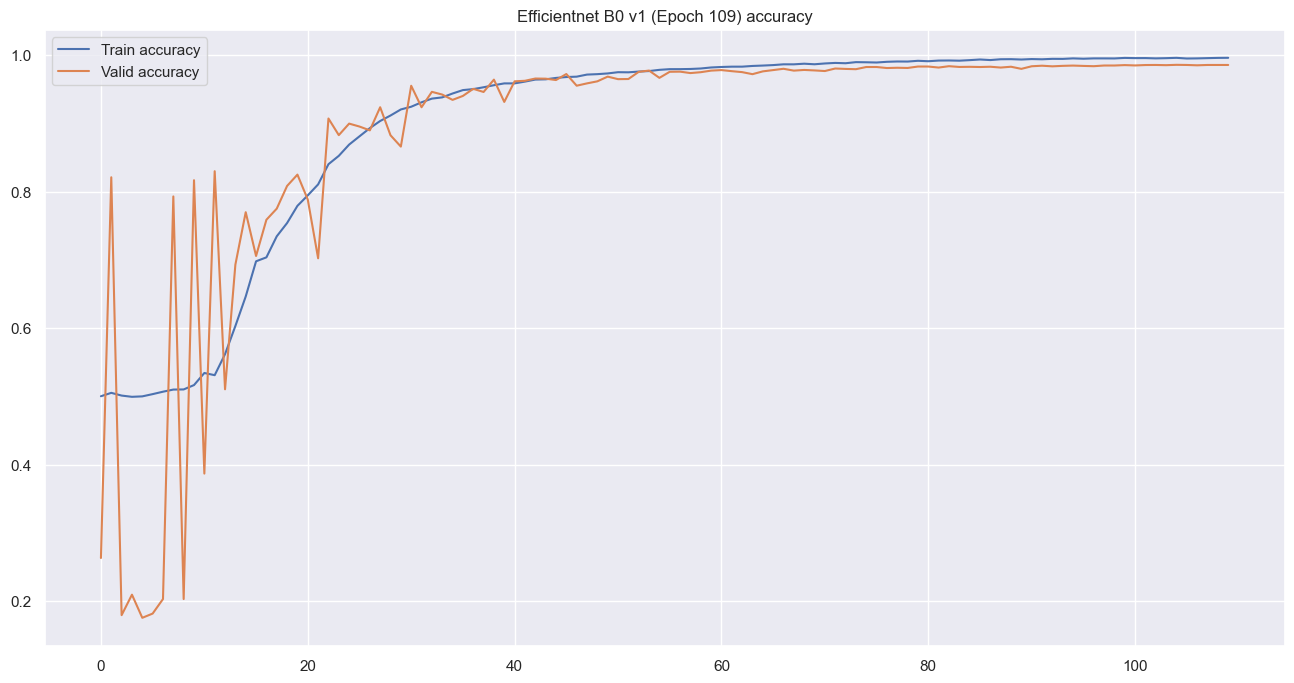

([1.1492537167072296,
  1.0648308837413787,
  1.0711976726531982,
  1.0597503145217895,
  0.9814159317493438,
  0.9142187579154968,
  0.8416323292255402,
  0.807908649301529,
  0.7664040783405304,
  0.7424023582935333,
  0.722852666425705,
  0.7189097907066345,
  0.7060599836826325,
  0.6887924964427948,
  0.6623320264816284,
  0.6226359640598297,
  0.6136315599203109,
  0.5822554793834687,
  0.5570026340007782,
  0.5218223198413849,
  0.5056009599685669,
  0.4859684369802475,
  0.44721151695251465,
  0.4299969258785248,
  0.40597679996490477,
  0.39032604906558993,
  0.37250079313516615,
  0.35736705408096314,
  0.3454817918300629,
  0.3333761766552925,
  0.32442122815847396,
  0.3120687642455101,
  0.3043359016418457,
  0.30172079014778136,
  0.29206022918224334,
  0.28516041219234467,
  0.2816787287116051,
  0.27757986468076706,
  0.27312842190265657,
  0.2668289885044098,
  0.26780039781332016,
  0.26242743356227877,
  0.25926692190170286,
  0.25749040101766585,
  0.254478454983234

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.amp import GradScaler
import torch
import gc

gc.collect()
torch.cuda.empty_cache()


model = efficientnet_b3(num_classes=2).to(device)
opt = AdamW(model.parameters(), lr=5e-4, weight_decay=1e-2)

warmup_epochs = 10
main_epochs = 100

warmup_scheduer = LinearLR(opt, start_factor=0.01, total_iters=warmup_epochs)
cosine_scheduler = CosineAnnealingLR(opt, T_max=main_epochs)
scheduler = SequentialLR(opt, schedulers=[warmup_scheduer, cosine_scheduler], milestones=[warmup_epochs])

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = GradScaler("cuda")

fit(
    model,
    train_loader,
    val_loader,
    opt,
    scheduler,
    loss_fn,
    device,
    warmup_epochs + main_epochs,
    title='Efficientnet B0 v1',
    save_path="C:\\Users\\PC\\Downloads\\dataset\\dataset\\checkpoints_efb0_v1"

)

## Тестирование модей, Ансамбль, Создание submisions (файлов ответа)

- Определить device [тык](#scrollTo=7567a797)

Функция для вывода распределения весов моделей

In [ ]:
def plot_weights_dist(model, model_name):
    weights = []
    for param in model.parameters():
        weights.extend(param.view(-1).cpu().detach().numpy())

    plt.figure(figsize=(10, 4))
    plt.hist(weights, bins=100, color='skyblue', edgecolor='black')
    plt.title(f"Распределение значений весов (w_i) в {model_name}")
    plt.xlabel("Значение веса")
    plt.ylabel("Количество")
    plt.grid(True, alpha=0.3)
    plt.show()

### Загрузка весов

#### resnet34 v4

In [ ]:
import gdown

url = "https://drive.google.com/uc?id=1gM3SCfia57gNxOVmrCy4dQvviH4Dp6Sr"
output = "/content/resnet34v4.pt"

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1gM3SCfia57gNxOVmrCy4dQvviH4Dp6Sr
From (redirected): https://drive.google.com/uc?id=1gM3SCfia57gNxOVmrCy4dQvviH4Dp6Sr&confirm=t&uuid=6ba783d7-bfee-49ff-b801-7fe79bb96f74
To: /content/resnet34v4.pt
100%|██████████| 85.3M/85.3M [00:01<00:00, 61.1MB/s]


'/content/resnet34v4.pt'

необходимые для запуска ссылки:
- [Перейти к аугментации Resnet34](#scrollTo=G6095_4kn87j)
- [Перейти к модели Resnet34](#scrollTo=EnmMCuGIH9KE)

In [ ]:
model = resnet34(num_classes=2).to(device)

weights_path = '/content/resnet34v4.pt'
state_dict = torch.load(weights_path, map_location=device)

model.load_state_dict(state_dict)
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Вывод весов

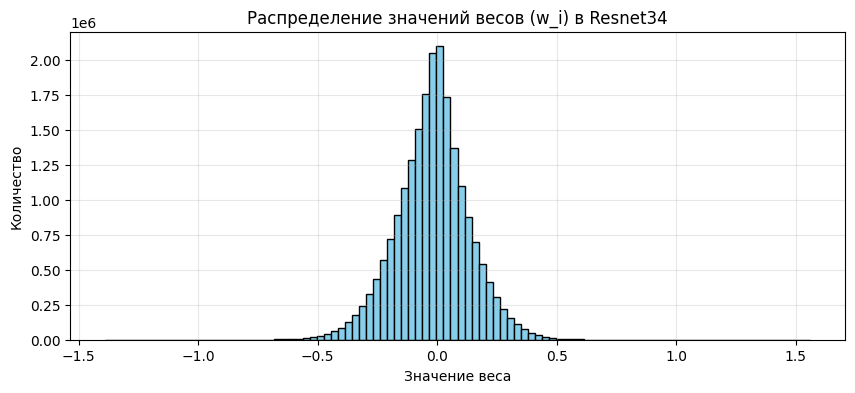

In [ ]:
import matplotlib.pyplot as plt

plot_weights_dist(model, "Resnet34")

#### resnet50 v1

In [ ]:
import gdown

url = "https://drive.google.com/uc?id=1ZHORq6IwyzjOlRciKomQMMygqA1Pr_y1"
output = "/content/resnet50v1.pt"

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1ZHORq6IwyzjOlRciKomQMMygqA1Pr_y1
From (redirected): https://drive.google.com/uc?id=1ZHORq6IwyzjOlRciKomQMMygqA1Pr_y1&confirm=t&uuid=00815560-deb0-40c0-85e1-f918d8681c42
To: /content/resnet50v1.pt
100%|██████████| 94.4M/94.4M [00:02<00:00, 32.4MB/s]


'/content/resnet50v1.pt'

необходимые для запуска ссылки:
- [Перейти к аугментации Resnet50](#scrollTo=G6095_4kn87j)
- [Перейти к модели Resnet50](#scrollTo=EnmMCuGIH9KE)

In [ ]:
model = resnet50(num_classes=2).to(device)

weights_path = '/content/resnet50v1.pt'
state_dict = torch.load(weights_path, map_location=device)

model.load_state_dict(state_dict)
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Вывод весов

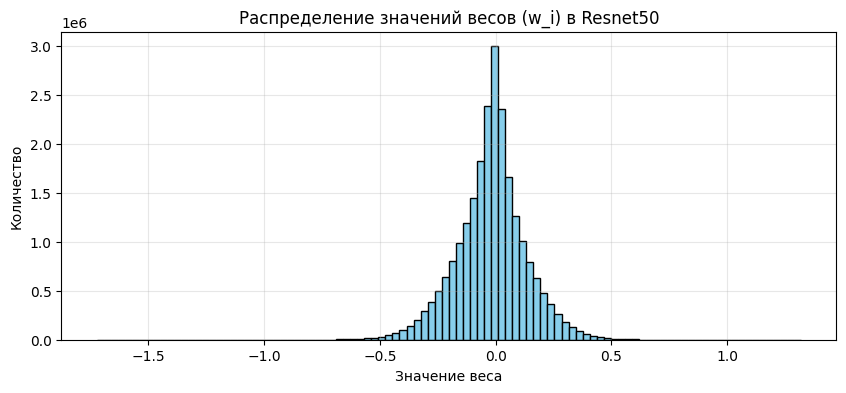

In [ ]:
import matplotlib.pyplot as plt

plot_weights_dist(model, "Resnet50")

#### convnext-nano v8

In [ ]:
import gdown

url = "https://drive.google.com/uc?id=1xONIlciTS8EwcSg3yIoD086LM7wAjttX"
output = "/content/convnext-nanov8.pt"

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1xONIlciTS8EwcSg3yIoD086LM7wAjttX
From (redirected): https://drive.google.com/uc?id=1xONIlciTS8EwcSg3yIoD086LM7wAjttX&confirm=t&uuid=09d021dc-eefe-4a03-8fcc-97fd5b3744c4
To: /content/convnext-nanov8.pt
100%|██████████| 59.9M/59.9M [00:00<00:00, 127MB/s]


'/content/convnext-nanov8.pt'

необходимые для запуска ссылки:
- [Перейти к аугментации Convnext-nano](#scrollTo=xcPerM0DpFDr)
- [Перейти к модели Convnext-nano](#scrollTo=yLnrPqXgI7Gq)

In [ ]:
model = convnext_nano(num_classes=2).to(device)

weights_path = '/content/convnext-nanov8.pt'
state_dict = torch.load(weights_path, map_location=device)

model.load_state_dict(state_dict)
model.to(device)
model.eval()

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 80, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((80,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(80, 80, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=80)
          (1): Permute()
          (2): LayerNorm((80,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=80, out_features=320, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=320, out_features=80, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth()
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(80, 80, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=80)
          (1): Permute()
          (2): LayerNorm((80,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=80, out_feature

Вывод весов

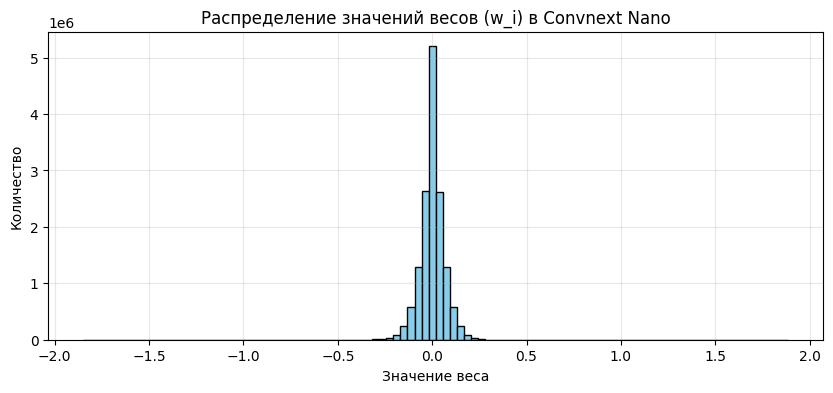

In [ ]:
import matplotlib.pyplot as plt

plot_weights_dist(model, "Convnext Nano")

#### regnet y 400mf v1

In [ ]:
import gdown

url = "https://drive.google.com/uc?id=1ns3pqLaz5Elidd7kkzNQeuFxbNCq3rMC"
output = "/content/regnet_y_400v1.pt"

gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1ns3pqLaz5Elidd7kkzNQeuFxbNCq3rMC
To: /content/regnet_y_400v1.pt
100%|██████████| 15.9M/15.9M [00:00<00:00, 28.8MB/s]


'/content/regnet_y_400v1.pt'

необходимые для запуска ссылки:
- [Перейти к аугментации Regnet](#scrollTo=mBbwvB1hpLPn)
- [Перейти к модели Regnet](#scrollTo=-sO2pEAEI-vk)

In [ ]:
model = regnet_y_400mf(num_classes=2)

weights_path = '/content/regnet_y_400v1.pt'

state_dict = torch.load(weights_path, map_location=device)

new_state_dict = {}
for k, v in state_dict.items():
    new_key = k.replace("fc.1.", "fc.")
    new_state_dict[new_key] = v

model.load_state_dict(new_state_dict)

model.to(device)
model.eval()

RegNet(
  (stem): SimpleStemIN(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (trunk_output): Sequential(
    (block1): AnyStage(
      (block1-0): ResBottleneckBlock(
        (proj): Conv2dNormActivation(
          (0): Conv2d(32, 48, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (f): BottleneckTransform(
          (a): Conv2dNormActivation(
            (0): Conv2d(32, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (b): Conv2dNormActivation(
            (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=6, bias=False)
            

Вывод весов

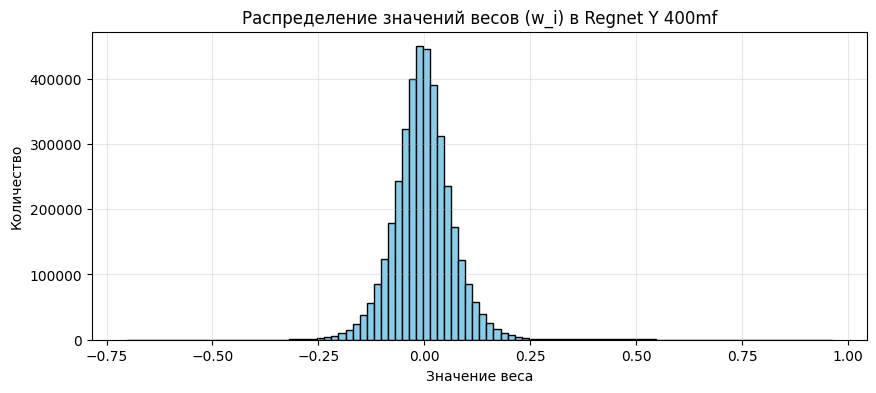

In [ ]:
import matplotlib.pyplot as plt

plot_weights_dist(model, "Regnet Y 400mf")

#### efficientnet b3 v1

In [ ]:
import gdown

url = "https://drive.google.com/uc?id=1xv_G-X4JxH0PPfEXa5VnIL_gA5dQlR4v"
output = "/content/efficientnetv1.pt"

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1xv_G-X4JxH0PPfEXa5VnIL_gA5dQlR4v
From (redirected): https://drive.google.com/uc?id=1xv_G-X4JxH0PPfEXa5VnIL_gA5dQlR4v&confirm=t&uuid=7d02095f-434e-43db-9d71-05a8c49ca073
To: /content/efficientnetv1.pt
100%|██████████| 43.4M/43.4M [00:00<00:00, 44.5MB/s]


'/content/efficientnetv1.pt'

необходимые для запуска ссылки:
- [Перейти к аугментации Efficientnet](#scrollTo=jFeaAaOLpXLM)
- [Перейти к модели Efficientnet](#scrollTo=WV5BqkdyJE0l)

In [ ]:
model = efficientnet_b3(num_classes=2)

weights_path = '/content/efficientnetv1.pt'

state_dict = torch.load(weights_path, map_location=device)

model.load_state_dict(state_dict)

model.to(device)
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

Вывод весов

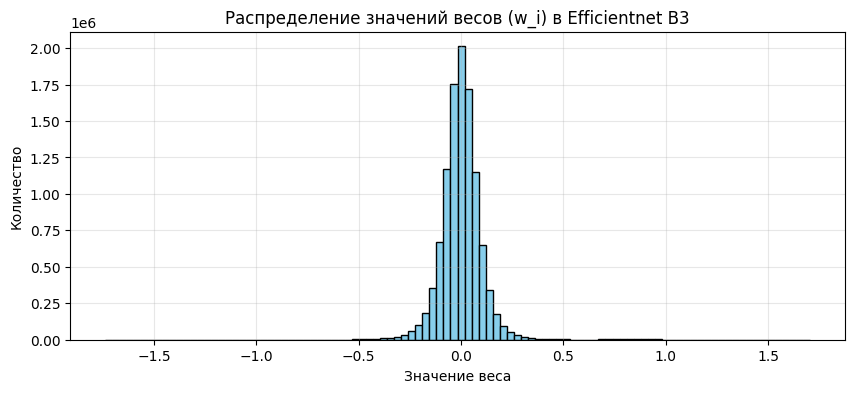

In [ ]:
import matplotlib.pyplot as plt

plot_weights_dist(model, "Efficientnet B3")

### Ансамблирование

Если тут ничего не будет, значит мы не успели

#### Ансабль v1 - Усреднение (0.977)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EnsembleModel(nn.Module):
    def __init__(self, paths=None, device='cpu'):
        super(EnsembleModel, self).__init__()
        self.model_res = resnet34(num_classes=2)
        self.model_conv = convnext_nano(num_classes=2)
        self.model_eff = efficientnet_b3(num_classes=2)

        if paths:
            self.model_res.load_state_dict(torch.load(paths['res'], map_location=device))
            self.model_conv.load_state_dict(torch.load(paths['conv'], map_location=device))
            self.model_eff.load_state_dict(torch.load(paths['eff'], map_location=device))

        self.to(device)

    def forward(self, x):
        # усредняем вероятности
        logits_res = self.model_res(x)
        logits_conv = self.model_conv(x)
        logits_eff = self.model_eff(x)

        prob_res = F.softmax(logits_res, dim=1)
        prob_conv = F.softmax(logits_conv, dim=1)
        prob_eff = F.softmax(logits_eff, dim=1)

        avg_probs = (prob_res + prob_conv + prob_eff) / 3.0

        return avg_probs

In [ ]:
# ссылки на пути
paths = {
    'res': '/content/resnet34v4.pt',
    'conv': '/content/convnext-nanov8.pt',
    'eff': '/content/efficientnetv1.pt'
}

ensemble = EnsembleModel(paths=paths, device=device)


torch.save(ensemble.state_dict(), f"/content/ensemblev1.pt")

##### Загрузить веса для теста ниже

In [ ]:
import gdown

url = "https://drive.google.com/uc?id=1s4bwXVluzHunuQCziucbkQonO6a1Wwc7"
output = "/content/ensemblev1.pt"

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1s4bwXVluzHunuQCziucbkQonO6a1Wwc7
From (redirected): https://drive.google.com/uc?id=1s4bwXVluzHunuQCziucbkQonO6a1Wwc7&confirm=t&uuid=269ceec9-719c-4439-85c3-2ac5989f96f3
To: /content/ensemblev1.pt
100%|██████████| 189M/189M [00:01<00:00, 131MB/s]


'/content/ensemblev1.pt'

In [ ]:
model = EnsembleModel()

state_dict = torch.load(output, map_location=device)

model.load_state_dict(state_dict)

model.to(device)


EnsembleModel(
  (model_res): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, t

#### Ансамбль v2 - Мета Модель (0.982)

Загружаем веса как и в предыдущем случае

In [ ]:
path_efficientnet = "/content/efficientnetv1.pt"
path_convnext = "/content/convnext-nanov8.pt"
path_resnet = "/content/resnet34v4.pt"

model_enf = efficientnet_b3(num_classes=2).to(device)
model_enf.load_state_dict(torch.load(path_efficientnet, map_location=device))

model_convnext = convnext_nano(num_classes=2).to(device)
model_convnext.load_state_dict(torch.load(path_convnext, map_location=device))

model_resnet = resnet34(num_classes=2).to(device)
model_resnet.load_state_dict(torch.load(path_resnet, map_location=device))

<All keys matched successfully>

Создаём наш классификатор

In [ ]:
import torch.nn as nn

class MetaModel(nn.Module):
    def __init__(self, n_models=3, n_classes=2):
        super(MetaModel, self).__init__()
        # На вход получаем вероятности от каждой модели
        # Если 3 модели и 2 класса, входной размер будет 3 * 2 = 6
        self.fc = nn.Sequential(
            nn.Linear(n_models * n_classes, 16),
            nn.ReLU(),
            nn.Linear(16, n_classes)
        )

    def forward(self, x):
        return self.fc(x)

meta_clf = MetaModel(n_models=3, n_classes=2).to(device)

Создаём класс с взаимодействием всех моделей

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm

class StackingEnsemble(nn.Module):
    def __init__(self, resnet, convnext, effnet):
        super().__init__()
        self.resnet = resnet
        self.convnext = convnext
        self.effnet = effnet

        self.meta_model = nn.Sequential(
            nn.Linear(3 * 2, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

        for model in [self.resnet, self.convnext, self.effnet]:
            for param in model.parameters():
                param.requires_grad = False

    def forward(self, x):
        self.resnet.eval()
        self.convnext.eval()
        self.effnet.eval()

        with torch.no_grad():
            out1 = torch.softmax(self.resnet(x), dim=1)
            out2 = torch.softmax(self.convnext(x), dim=1)
            out3 = torch.softmax(self.effnet(x), dim=1)

        meta_input = torch.cat((out1, out2, out3), dim=1)
        return self.meta_model(meta_input)

Создаём специальные простые функции обучения

In [ ]:
def train_meta_epoch(model, optimizer, loss_fn, data_loader, device):
    model.train() # Обучаем только мета-слой
    total_loss = 0
    total_correct = 0

    for x, y in tqdm(data_loader, desc="Training Meta-Layer"):
        x, y = x.to(device), y.to(device).long()

        optimizer.zero_grad()
        output = model(x)
        loss = loss_fn(output, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_correct += (output.argmax(dim=1) == y).sum().item()

    return total_loss / len(data_loader), total_correct / len(data_loader.sampler)

def evaluate_cpu(model, data_loader, loss_fn, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    with torch.no_grad():
        for x, y in tqdm(data_loader):
            x, y = x.to(device), y.to(device).long()
            output = model(x)
            loss = loss_fn(output, y)
            total_loss += loss.item()
            total_correct += (output.argmax(dim=1) == y).sum().item()

    return total_loss / len(data_loader), total_correct / len(data_loader.sampler)

Создаём лоадеры на основе val

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset

val_labels_for_split = df.iloc[val_idx, 1]

#  60% на обучение, 40% на итоговый тест
meta_train_indices, meta_test_indices = train_test_split(
    val_idx,
    test_size=0.4,
    stratify=val_labels_for_split,
    random_state=42
)

# Создаем сабсеты
meta_train_data = Subset(val_dataset, meta_train_indices)
meta_test_data = Subset(val_dataset, meta_test_indices)

meta_train_loader = DataLoader(
    meta_train_data,
    batch_size=16,
    num_workers=4,
    shuffle=True,
    pin_memory=False
)

meta_test_loader = DataLoader(
    meta_test_data,
    batch_size=16,
    num_workers=4,
    shuffle=False,
    pin_memory=False
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
ensemble_model = StackingEnsemble(model_resnet, model_convnext, model_enf).to(device)

optimizer = torch.optim.Adam(ensemble_model.meta_model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

# Цикл обучения (упрощенный fit)
num_epochs = 10
for epoch in range(num_epochs):
    train_loss, train_acc = train_meta_epoch(ensemble_model, optimizer, loss_fn, meta_train_loader, device)
    val_loss, val_acc = evaluate_cpu(ensemble_model, meta_test_loader, loss_fn, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print("-" * 30)

torch.save(ensemble_model.meta_model.state_dict(), "stacking_meta_head.pt")

Training Meta-Layer:   0%|          | 0/375 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Training Meta-Layer: 100%|██████████| 375/375 [00:47<00:00,  7.86it/s]


Epoch 1/10
Train Loss: 0.2670 | Train Acc: 0.9158
Val Loss: 0.0635 | Val Acc: 0.9880
------------------------------


Training Meta-Layer: 100%|██████████| 375/375 [00:47<00:00,  7.93it/s]


Epoch 2/10
Train Loss: 0.0399 | Train Acc: 0.9902
Val Loss: 0.0436 | Val Acc: 0.9882
------------------------------


Training Meta-Layer: 100%|██████████| 375/375 [00:45<00:00,  8.22it/s]


...

Epoch 8/10
Train Loss: 0.0296 | Train Acc: 0.9913
Val Loss: 0.0431 | Val Acc: 0.9895
------------------------------


Training Meta-Layer: 100%|██████████| 375/375 [00:45<00:00,  8.19it/s]


Epoch 9/10
Train Loss: 0.0296 | Train Acc: 0.9910
Val Loss: 0.0429 | Val Acc: 0.9895
------------------------------


Training Meta-Layer: 100%|██████████| 375/375 [00:45<00:00,  8.23it/s]


Epoch 10/10
Train Loss: 0.0294 | Train Acc: 0.9910
Val Loss: 0.0431 | Val Acc: 0.9895
------------------------------


Визуализация обучения

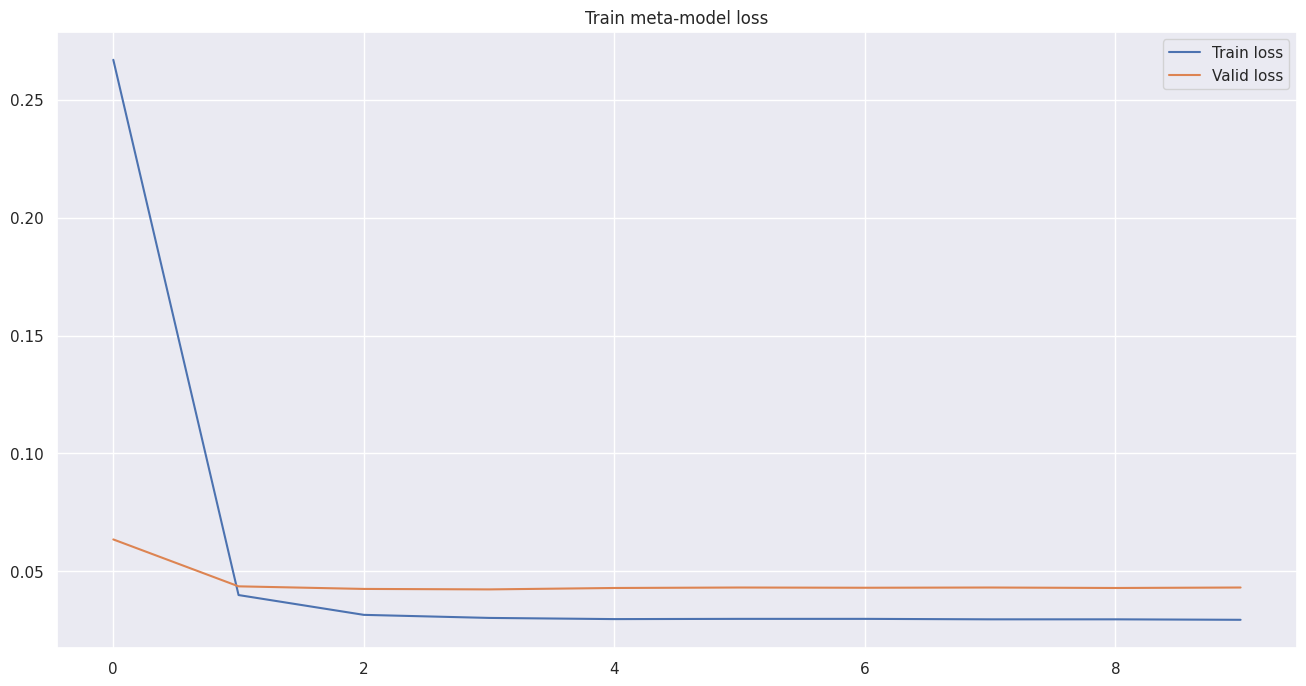

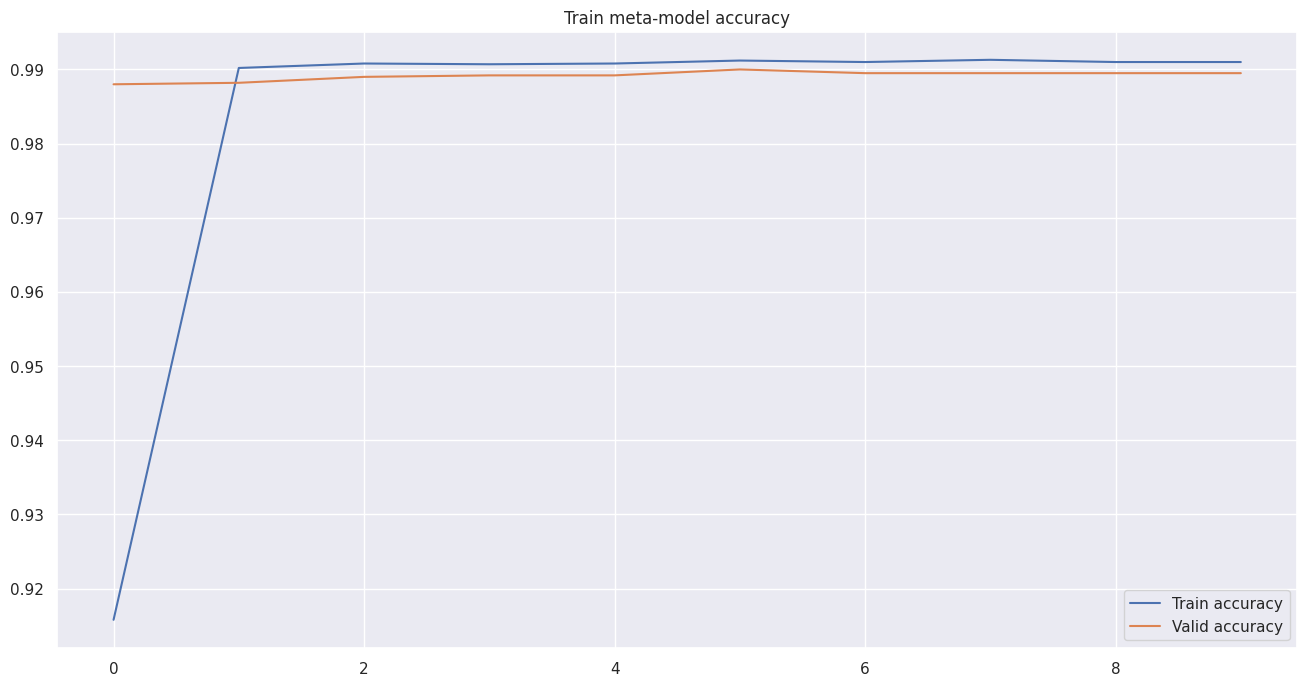

In [ ]:
train_loss = [0.2670, 0.0399, 0.0315, 0.0302, 0.0297, 0.0298, 0.0298, 0.0296, 0.0296, 0.0294]
train_acc = [0.9158, 0.9902, 0.9908, 0.9907, 0.9908, 0.9912, 0.9910, 0.9913, 0.9910, 0.9910]
val_loss = [0.0635, 0.0436, 0.0425, 0.0423, 0.0429, 0.0431, 0.0430, 0.0431, 0.0429, 0.0431]
val_acc = [0.9880, 0.9882, 0.9890, 0.9892, 0.9892, 0.9900, 0.9895, 0.9895, 0.9895, 0.9895]
plot_stats(train_loss, val_loss, train_acc, val_acc, "Train meta-model")

Смотрим веса

Форма матрицы весов: (16, 6)
Максимальный вес: 0.8694
Минимальный вес: -0.7527
Среднее смещение (bias): 0.1490


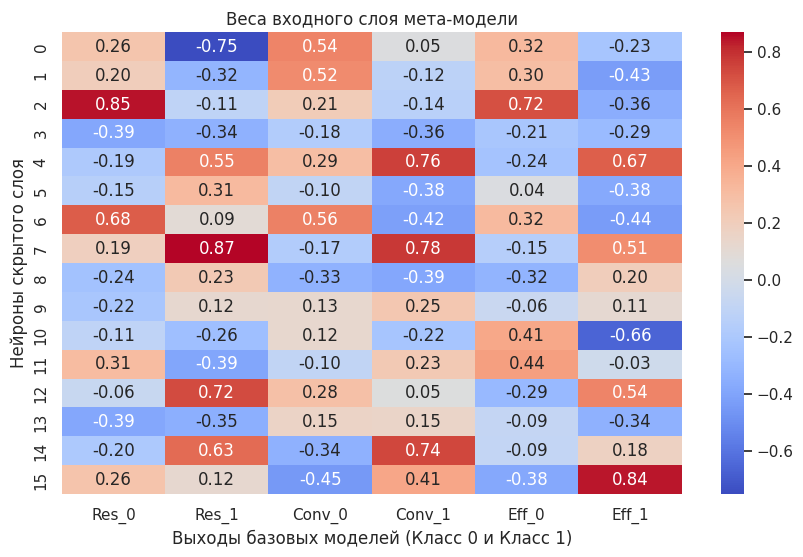

In [ ]:
weights = ensemble_model.meta_model[0].weight.data.cpu().numpy()
biases = ensemble_model.meta_model[0].bias.data.cpu().numpy()

print(f"Форма матрицы весов: {weights.shape}")
print(f"Максимальный вес: {weights.max():.4f}")
print(f"Минимальный вес: {weights.min():.4f}")
print(f"Среднее смещение (bias): {biases.mean():.4f}")

# Визуализируем веса первого слоя, чтобы понять, на какие входные каналы он смотрит сильнее
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(weights, annot=True, cmap='coolwarm', fmt=".2f",
            xticklabels=['Res_0', 'Res_1', 'Conv_0', 'Conv_1', 'Eff_0', 'Eff_1'])
plt.title("Веса входного слоя мета-модели")
plt.xlabel("Выходы базовых моделей (Класс 0 и Класс 1)")
plt.ylabel("Нейроны скрытого слоя")
plt.show()

##### Загрузка весов модели

In [ ]:
import gdown

url = "https://drive.google.com/uc?id=1YOywuvIUWYYTJj-TwlyW2dcX3-jKIlM5"
output = "/content/ensemblev2.pt"

gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1YOywuvIUWYYTJj-TwlyW2dcX3-jKIlM5
To: /content/ensemblev2.pt
100%|██████████| 3.21k/3.21k [00:00<00:00, 10.1MB/s]


'/content/ensemblev2.pt'

In [ ]:
# пожалуйста, запустите ячейки с архитектурами
model_res = resnet34(num_classes=2).to(device)
model_convnext = convnext_nano(num_classes=2).to(device)
model_eff = efficientnet_b3(num_classes=2).to(device)

model_res.load_state_dict(torch.load("/content/resnet34v4.pt", map_location=device))
model_convnext.load_state_dict(torch.load("/content/convnext-nanov8.pt", map_location=device))
model_eff.load_state_dict(torch.load("/content/efficientnetv1.pt", map_location=device))

ensemble_model = StackingEnsemble(model_res, model_convnext, model_eff).to(device)

ensemble_model.meta_model.load_state_dict(torch.load("/content/ensemblev2.pt", map_location=device))

ensemble_model.eval()

StackingEnsemble(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, t

### Сами тесты

- к загрузке данных [тык](#scrollTo=qDI8ZM3LENfJ)
- к созданию лоадеров [тык](#scrollTo=KuKChkqcB9WV)


In [ ]:
from sklearn.metrics import f1_score

def validate_checkpoint(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # average='macro' считает F1 для каждого класса и усредняет (хорошо для дисбаланса)
    # average='binary' если у тебя строго 0 и 1 и важен только один класс
    score = f1_score(all_labels, all_preds, average='macro')
    return score

In [ ]:
validate_checkpoint(model, val_loader, device) # лоадер не тот поставил, поэтому такое случилось ниже (сейчас всё нормально)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


0.9999749993149172

### Создание submissions

In [ ]:
import torch
import pandas as pd
from tqdm import tqdm
import os

def generate_submission(model, test_loader, device, checkpoint_path=None, output_name='submission.csv'):
    # загружаю чекпоинт
    if checkpoint_path is not None:
      model.load_state_dict(torch.load(checkpoint_path, map_location=device))
      model.to(device)
    model.eval()

    ids = []
    predictions = []

    with torch.no_grad():
        for x, img_ids in tqdm(test_loader):
            x = x.to(device)
            outputs = model(x)

            preds = torch.argmax(outputs, dim=1)

            ids.extend(img_ids)
            predictions.extend(preds.cpu().numpy())

    # Формируем DataFrame
    submission = pd.DataFrame({
        'id': ids,
        'target_feature': predictions
    })

    submission = submission.sort_values(by='id')

    submission.to_csv(output_name, index=False)

    submission.columns = ['id', 'target_feature']
    submission.columns = submission.columns.str.strip()

    submission['id'] = submission['id'].astype(int)
    submission['target_feature'] = submission['target_feature'].astype(int)

    submission = submission.sort_values(by='id').reset_index(drop=True)

    submission.to_csv('submission.csv', index=False)

generate_submission(model, test_loader, device)

100%|██████████| 313/313 [01:36<00:00,  3.26it/s]


In [ ]:
import torch.nn.functional as F
import torchvision.transforms.functional as TF

def generate_submission_max_tta(model, test_loader, device, checkpoint_path=None, output_name='submission_tta.csv'):
    if checkpoint_path is not None:
      model.load_state_dict(torch.load(checkpoint_path, map_location=device))
      model.to(device)
    model.eval()

    ids = []
    predictions = []

    with torch.no_grad():
        for x, img_ids in tqdm(test_loader):
            x = x.to(device)

            # Собираем список всех вариаций (Augmentations)
            tta_variants = [
                x,
                torch.flip(x, dims=[3])
            ]

            # Прогоняем каждую вариацию через модель и собираем вероятности
            batch_probs = []
            for variant in tta_variants:
                logits = model(variant)
                probs = F.softmax(logits, dim=1)
                batch_probs.append(probs)

            # Усредняем вероятности всех 7 вариаций
            avg_probs = torch.mean(torch.stack(batch_probs), dim=0)

            # Выбираем финальный класс (индекс 1 для фейка, если порядок такой)
            preds = torch.argmax(avg_probs, dim=1)

            ids.extend(img_ids)
            predictions.extend(preds.cpu().numpy())

    submission = pd.DataFrame({
        'id': ids,
        'target_feature': predictions
    })

    submission['id'] = submission['id'].astype(int)
    submission['target_feature'] = submission['target_feature'].astype(int)

    submission = submission.sort_values(by='id').reset_index(drop=True)

    submission.to_csv(output_name, index=False)
    print(f"Submission сохранен в {output_name}")


generate_submission_max_tta(model, test_loader, device)

Запуск MAX-TTA для None...


100%|██████████| 313/313 [02:37<00:00,  1.99it/s]

Submission сохранен в submission_tta.csv
